# Amazon Fashion Analysis 

In this jupyter notebook I will analyze the amazon fashion dataset till 2023.

# Research Questions

1. How is product performance associated with review and description length, and to what extent is it influenced by price?

2. Which factors are most strongly associated with store level populrity and success?

3. What is the product popularity through seasons and has that been consistent over the years?

## Importing Libraries and Tools

In [1]:
import os
import numpy as np # linear algebra
import pandas as pd # data processing
import matplotlib.pyplot as plt
import seaborn as sns
import gzip #the json data is in zip file 
import json

Compressed vs uncompressed JSON mainly affects disk space, I/O speed, and how you load the data, not the analysis itself. So, I will be used compressed json.

### Overview of review and meta dataset

In [2]:
#review dataset
df1 = pd.read_json("Amazon_Fashion.jsonl.gz", lines=True, compression="gzip")
df1.head()

,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase
0,5,Pretty locket,I think this locket is really pretty. The insi...,[],B00LOPVX74,B00LOPVX74,AGBFYI2DDIKXC5Y4FARTYDTQBMFQ,2020-01-09 00:06:34.489,3,True
1,5,A,Great,[],B07B4JXK8D,B07B4JXK8D,AFQLNQNQYFWQZPJQZS6V3NZU4QBQ,2020-12-20 01:04:06.701,0,True
2,2,Two Stars,One of the stones fell out within the first 2 ...,[],B007ZSEQ4Q,B007ZSEQ4Q,AHITBJSS7KYUBVZPX7M2WJCOIVKQ,2015-05-23 01:33:48.000,3,True
3,1,Won’t buy again,Crappy socks. Money wasted. Bought to wear wit...,[],B07F2BTFS9,B07F2BTFS9,AFVNEEPDEIH5SPUN5BWC6NKL3WNQ,2018-12-31 20:57:27.095,2,True
4,5,I LOVE these glasses,I LOVE these glasses! They fit perfectly over...,[],B00PKRFU4O,B00XESJTDE,AHSPLDNW5OOUK2PLH7GXLACFBZNQ,2015-08-13 14:29:26.000,0,True


In [3]:
df1.info()
df1.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500939 entries, 0 to 2500938
Data columns (total 10 columns):
 #   Column             Dtype         
---  ------             -----         
 0   rating             int64         
 1   title              object        
 2   text               object        
 3   images             object        
 4   asin               object        
 5   parent_asin        object        
 6   user_id            object        
 7   timestamp          datetime64[ns]
 8   helpful_vote       int64         
 9   verified_purchase  bool          
dtypes: bool(1), datetime64[ns](1), int64(2), object(6)
memory usage: 174.1+ MB


,rating,timestamp,helpful_vote
count,2.500939e+06,2500939,2.500939e+06
mean,3.969467e+00,2018-11-29 06:21:51.333767424,5.658635e-01
min,1.000000e+00,2002-05-07 01:51:28,0.000000e+00
25%,3.000000e+00,2017-04-11 13:16:35,0.000000e+00
50%,5.000000e+00,2018-12-27 12:54:30.036999936,0.000000e+00
75%,5.000000e+00,2020-09-02 18:27:05.002500096,0.000000e+00
max,5.000000e+00,2023-09-11 03:24:38.515000,9.540000e+02
std,1.427171e+00,NaN,3.785762e+00


In [4]:
#show missing value in data
print(f"Missing Value = {df1.isnull().sum()}")

Missing Value = rating               0
title                0
text                 0
images               0
asin                 0
parent_asin          0
user_id              0
timestamp            0
helpful_vote         0
verified_purchase    0
dtype: int64


In [5]:
#meta dataset
df2 = pd.read_json("meta_Amazon_Fashion.jsonl.gz", lines=True, compression="gzip")
df2.head()

,main_category,title,average_rating,rating_number,features,description,price,images,videos,store,categories,details,parent_asin,bought_together
0,AMAZON FASHION,YUEDGE 5 Pairs Men's Moisture Control Cushione...,4.6,16,[],[],NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[],GiveGift,[],{'Package Dimensions': '10.31 x 8.5 x 1.73 inc...,B08BHN9PK5,NaN
1,AMAZON FASHION,DouBCQ Women's Palazzo Lounge Wide Leg Casual ...,4.1,7,"[Drawstring closure, Machine Wash]",[],NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[],DouBCQ,[],{'Package Dimensions': '15 x 10.2 x 0.4 inches...,B08R39MRDW,NaN
2,AMAZON FASHION,Pastel by Vivienne Honey Vanilla Girls' Trapez...,4.3,11,"[Zipper closure, Hand Wash Only]",[],NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[],Pastel by Vivienne,[],"{'Is Discontinued By Manufacturer': 'No', 'Pac...",B077KJHCJ4,NaN
3,AMAZON FASHION,Mento Streamtail,2.0,1,"[Thermoplastic Rubber sole, High Density Premi...",[Slip on the Women's Mento and you're ready to...,29.81,[{'thumb': 'https://m.media-amazon.com/images/...,[],Guy Harvey,[],{'Package Dimensions': '11.22 x 4.72 x 4.33 in...,B0811M2JG9,NaN
4,AMAZON FASHION,RONNOX Women's 3-Pairs Bright Colored Calf Com...,4.3,3032,"[Pull On closure, Size Guide: ""S"" fits calf 10...",[Ronnox Calf Sleeves - Allowing Your Body to P...,17.99,[{'thumb': 'https://m.media-amazon.com/images/...,[{'title': 'HONEST Review: RONNOX Women's 3-Pa...,RONNOX,[],"{'Is Discontinued By Manufacturer': 'No', 'Pac...",B07SB2892S,NaN


In [6]:
df2.info()
df2.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 826108 entries, 0 to 826107
Data columns (total 14 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   main_category    826108 non-null  object 
 1   title            826108 non-null  object 
 2   average_rating   826108 non-null  float64
 3   rating_number    826108 non-null  int64  
 4   features         826108 non-null  object 
 5   description      826108 non-null  object 
 6   price            50249 non-null   float64
 7   images           826108 non-null  object 
 8   videos           826108 non-null  object 
 9   store            799270 non-null  object 
 10  categories       826108 non-null  object 
 11  details          826108 non-null  object 
 12  parent_asin      826108 non-null  object 
 13  bought_together  0 non-null       float64
dtypes: float64(3), int64(1), object(10)
memory usage: 88.2+ MB


,average_rating,rating_number,price,bought_together
count,826108.000000,826108.000000,50249.000000,0.0
mean,3.910660,17.942204,40.795929,NaN
std,0.982282,221.792730,154.089435,NaN
min,1.000000,1.000000,0.010000,NaN
25%,3.400000,2.000000,11.790000,NaN
50%,4.000000,4.000000,19.890000,NaN
75%,4.700000,10.000000,34.990000,NaN
max,5.000000,46299.000000,13000.000000,NaN


In [7]:
#show missing value in data
print(f"Missing Value = {df2.isnull().sum()}")

Missing Value = main_category           0
title                   0
average_rating          0
rating_number           0
features                0
description             0
price              775859
images                  0
videos                  0
store               26838
categories              0
details                 0
parent_asin             0
bought_together    826108
dtype: int64


### After having a look at review and meta dataset. I can say that :- 

1. Meta dataset has 8,26,106 rows
2. Review dataset has 25,00,939 rows
3. It is best to do analysis with both the datasets rather than just one of them. 
4. Price has a lot of missing values. So, when sub sampling the dataset, we need to consider this factor for meta dataset.
5. Store's missing values will need to be handled.
6. The bought_together attribute has zero values.

### Size of both the compressed datasets 

In [8]:
print(f"Review dataset size: {os.path.getsize('Amazon_Fashion.jsonl.gz') / 1024**2:.2f} MB")
print(f"Meta dataset size: {os.path.getsize('meta_Amazon_Fashion.jsonl.gz') / 1024**2:.2f} MB")


Review dataset size: 278.88 MB
Meta dataset size: 213.91 MB


### Sub sampling the datasets

In [9]:
def load_first_n_jsonl_gz(path, n=5000):
    rows = []
    with gzip.open(path, "rt", encoding="utf-8") as f:
        for i, line in enumerate(f):
            if i >= n:
                break
            rows.append(json.loads(line))
    return pd.DataFrame(rows)

# 1. Load first 5000 review rows
df_reviews_5k = load_first_n_jsonl_gz("Amazon_Fashion.jsonl.gz", n=5000)

# 2. Load first 5000 meta rows
df_meta_5k = load_first_n_jsonl_gz("meta_Amazon_Fashion.jsonl.gz", n=5000)

# Optional: save for later use
df_reviews_5k.to_json("sample_reviews_5000.json", orient="records", lines=True)
df_meta_5k.to_json("sample_meta_5000.json", orient="records", lines=True)

print("Reviews sample shape:", df_reviews_5k.shape)
print("Meta sample shape:", df_meta_5k.shape)


Reviews sample shape: (5000, 10)
Meta sample shape: (5000, 14)


In [10]:
df_reviews_5k.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   rating             5000 non-null   float64
 1   title              5000 non-null   object 
 2   text               5000 non-null   object 
 3   images             5000 non-null   object 
 4   asin               5000 non-null   object 
 5   parent_asin        5000 non-null   object 
 6   user_id            5000 non-null   object 
 7   timestamp          5000 non-null   int64  
 8   helpful_vote       5000 non-null   int64  
 9   verified_purchase  5000 non-null   bool   
dtypes: bool(1), float64(1), int64(2), object(6)
memory usage: 356.6+ KB


as seen there are no missing values in reviews dataset

In [11]:
df_meta_5k.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   main_category    5000 non-null   object 
 1   title            5000 non-null   object 
 2   average_rating   5000 non-null   float64
 3   rating_number    5000 non-null   int64  
 4   features         5000 non-null   object 
 5   description      5000 non-null   object 
 6   price            594 non-null    float64
 7   images           5000 non-null   object 
 8   videos           5000 non-null   object 
 9   store            4840 non-null   object 
 10  categories       5000 non-null   object 
 11  details          5000 non-null   object 
 12  parent_asin      5000 non-null   object 
 13  bought_together  0 non-null      object 
dtypes: float64(2), int64(1), object(11)
memory usage: 547.0+ KB


Issue - 594 non null values for prices, which was predicted before. 
Solution - Streaming the big meta file line by line and only keeping rows where price is present, until I’ve collected 5000 such rows.

In [12]:
import math

def load_n_with_nonnull_price(path, n=5000):
    rows = []
    with gzip.open(path, "rt", encoding="utf-8") as f:
        for line in f:
            obj = json.loads(line)
            # adjust key name if it's different
            if "price" in obj and obj["price"] is not None and not (isinstance(obj["price"], float) and math.isnan(obj["price"])):
                rows.append(obj)
                if len(rows) >= n:
                    break
    return pd.DataFrame(rows)

df_meta_5k_price = load_n_with_nonnull_price("meta_Amazon_Fashion.jsonl.gz", n=5000)
print(df_meta_5k_price["price"].notna().sum())  # should be 5000
df_meta_5k_price.to_csv("meta_5k_price_notnull.csv", index=False)


5000


In [13]:
df_meta_5k_price.info()
df_meta_5k_price.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   main_category    5000 non-null   object 
 1   title            5000 non-null   object 
 2   average_rating   5000 non-null   float64
 3   rating_number    5000 non-null   int64  
 4   features         5000 non-null   object 
 5   description      5000 non-null   object 
 6   price            5000 non-null   float64
 7   images           5000 non-null   object 
 8   videos           5000 non-null   object 
 9   store            4949 non-null   object 
 10  categories       5000 non-null   object 
 11  details          5000 non-null   object 
 12  parent_asin      5000 non-null   object 
 13  bought_together  0 non-null      object 
dtypes: float64(2), int64(1), object(11)
memory usage: 547.0+ KB


,average_rating,rating_number,price
count,5000.000000,5000.000000,5000.00000
mean,4.175120,225.401800,34.98081
std,0.761024,1182.864618,80.89214
min,1.000000,1.000000,0.01000
25%,3.900000,3.000000,11.99000
50%,4.300000,14.000000,19.67500
75%,4.700000,79.000000,34.50000
max,5.000000,36058.000000,2695.00000


Perfect, now we will use. These sample sets for review and meta data.
we are using these dataframes subsamples :-
1. df_meta_5k_price
2. df_reviews_5k

# Parsing and cleaning 

#### drop the columns which are not needed in these dataframes.

- Drop images from df_reviews_5k
  
- Drop images, videos, and bought_together from df_meta_5k_price

In [14]:
# For reviews sample
cols_to_drop_reviews = [c for c in ["images"] if c in df_reviews_5k.columns]
df_reviews_5k = df_reviews_5k.drop(columns=cols_to_drop_reviews)

# For meta sample
cols_to_drop_meta = [c for c in ["images", "videos", "bought_together"] if c in df_meta_5k_price.columns]
df_meta_5k_price = df_meta_5k_price.drop(columns=cols_to_drop_meta)


In [15]:
df_reviews_5k.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   rating             5000 non-null   float64
 1   title              5000 non-null   object 
 2   text               5000 non-null   object 
 3   asin               5000 non-null   object 
 4   parent_asin        5000 non-null   object 
 5   user_id            5000 non-null   object 
 6   timestamp          5000 non-null   int64  
 7   helpful_vote       5000 non-null   int64  
 8   verified_purchase  5000 non-null   bool   
dtypes: bool(1), float64(1), int64(2), object(5)
memory usage: 317.5+ KB


In [16]:
df_meta_5k_price.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   main_category   5000 non-null   object 
 1   title           5000 non-null   object 
 2   average_rating  5000 non-null   float64
 3   rating_number   5000 non-null   int64  
 4   features        5000 non-null   object 
 5   description     5000 non-null   object 
 6   price           5000 non-null   float64
 7   store           4949 non-null   object 
 8   categories      5000 non-null   object 
 9   details         5000 non-null   object 
 10  parent_asin     5000 non-null   object 
dtypes: float64(2), int64(1), object(8)
memory usage: 429.8+ KB


# Missing Values

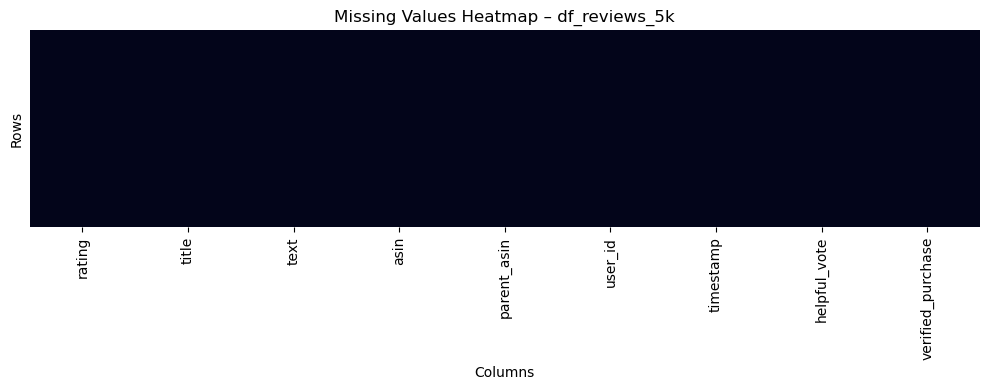

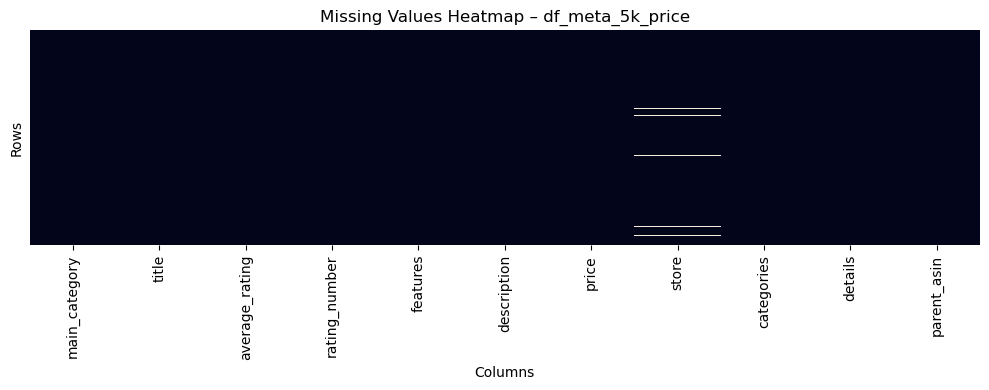

In [17]:
# Reviews missingness heatmap
plt.figure(figsize=(10, 4))
sns.heatmap(df_reviews_5k.isna(),
            cbar=False,
            yticklabels=False)
plt.title("Missing Values Heatmap – df_reviews_5k")
plt.xlabel("Columns")
plt.ylabel("Rows")
plt.tight_layout()
plt.show()

# Meta missingness heatmap
plt.figure(figsize=(10, 4))
sns.heatmap(df_meta_5k_price.isna(),
            cbar=False,
            yticklabels=False)
plt.title("Missing Values Heatmap – df_meta_5k_price")
plt.xlabel("Columns")
plt.ylabel("Rows")
plt.tight_layout()
plt.show()


In [18]:
# Count missing values in 'store'
missing_store = df_meta_5k_price["store"].isna().sum()
print("Missing values in 'store':", missing_store)

# Drop rows where 'store' is missing
df_meta_5k_price = df_meta_5k_price.dropna(subset=["store"])


Missing values in 'store': 51


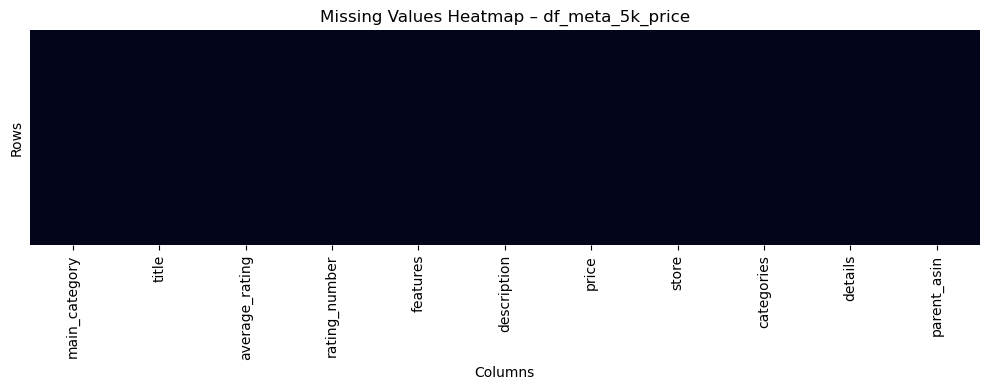

In [19]:
# Meta missingness heatmap
plt.figure(figsize=(10, 4))
sns.heatmap(df_meta_5k_price.isna(),
            cbar=False,
            yticklabels=False)
plt.title("Missing Values Heatmap – df_meta_5k_price")
plt.xlabel("Columns")
plt.ylabel("Rows")
plt.tight_layout()
plt.show()

now we have no missing values 

#### standardising timestamp

In [20]:
print(df_reviews_5k.columns)
print(df_reviews_5k["timestamp"].dtype)

Index(['rating', 'title', 'text', 'asin', 'parent_asin', 'user_id',
       'timestamp', 'helpful_vote', 'verified_purchase'],
      dtype='object')
int64


In [21]:
# convert the int64 column to datetime
df_reviews_5k["timestamp"] = pd.to_datetime(
    df_reviews_5k["timestamp"],
    unit="ms",
    origin="unix"
)


In [22]:
# recreate review_date
df_reviews_5k["review_date"] = df_reviews_5k["timestamp"].dt.date


In [24]:
df_reviews_5k["year"] = df_reviews_5k["timestamp"].dt.year
df_reviews_5k["month"] = df_reviews_5k["timestamp"].dt.month


In [25]:
print(df_reviews_5k.columns)          # sanity check
print(df_reviews_5k.columns.tolist())


Index(['rating', 'title', 'text', 'asin', 'parent_asin', 'user_id',
       'timestamp', 'helpful_vote', 'verified_purchase', 'review_date', 'year',
       'month'],
      dtype='object')
['rating', 'title', 'text', 'asin', 'parent_asin', 'user_id', 'timestamp', 'helpful_vote', 'verified_purchase', 'review_date', 'year', 'month']


In [29]:
print(df_reviews_5k.columns.tolist())
print(df_reviews_5k["year"].head())
print(df_reviews_5k["month"].head())


['rating', 'title', 'text', 'asin', 'parent_asin', 'user_id', 'helpful_vote', 'verified_purchase', 'year', 'month']
0    2020
1    2020
2    2015
3    2018
4    2015
Name: year, dtype: int32
0     1
1    12
2     5
3    12
4     8
Name: month, dtype: int32


In [30]:
print(df_reviews_5k["year"].head())
print(df_reviews_5k["month"].head())


0    2020
1    2020
2    2015
3    2018
4    2015
Name: year, dtype: int32
0     1
1    12
2     5
3    12
4     8
Name: month, dtype: int32


In [89]:
df_reviews_5k.head()
df_reviews_5k.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   rating             5000 non-null   float64
 1   title              5000 non-null   object 
 2   text               5000 non-null   object 
 3   asin               5000 non-null   object 
 4   parent_asin        5000 non-null   object 
 5   user_id            5000 non-null   object 
 6   helpful_vote       5000 non-null   int64  
 7   verified_purchase  5000 non-null   bool   
 8   year               5000 non-null   int32  
 9   month              5000 non-null   int32  
dtypes: bool(1), float64(1), int32(2), int64(1), object(5)
memory usage: 317.5+ KB


# SQL QUERIES

checking if everything is in right formart to store the dataframes as tables in db

In [26]:
import sqlite3
import csv

In [27]:
for col in df_reviews_5k.columns:
    print(col, type(df_reviews_5k[col].iloc[0]))

for col in df_meta_5k_price.columns:
    print(col, type(df_meta_5k_price[col].iloc[0]))


rating <class 'numpy.float64'>
title <class 'str'>
text <class 'str'>
asin <class 'str'>
parent_asin <class 'str'>
user_id <class 'str'>
timestamp <class 'pandas._libs.tslibs.timestamps.Timestamp'>
helpful_vote <class 'numpy.int64'>
verified_purchase <class 'numpy.bool'>
review_date <class 'datetime.date'>
year <class 'numpy.int32'>
month <class 'numpy.int32'>
main_category <class 'str'>
title <class 'str'>
average_rating <class 'numpy.float64'>
rating_number <class 'numpy.int64'>
features <class 'list'>
description <class 'list'>
price <class 'numpy.float64'>
store <class 'str'>
categories <class 'list'>
details <class 'dict'>
parent_asin <class 'str'>


SQL won't take in list or dict. so I convert it to json string.


In [28]:
cols_complex = ["features", "description", "categories", "details"]

for col in cols_complex:
    if col in df_meta_5k_price.columns:
        df_meta_5k_price[col] = df_meta_5k_price[col].apply(
            lambda x: json.dumps(x) if isinstance(x, (list, dict)) else x
        )


Now reviews_5k and meta_5k_price exist as tables inside database.db

In [29]:
conn = sqlite3.connect("database.db")
flag='Y'
cursor = conn.cursor()
conn.execute("PRAGMA foreign_keys = ON;") #activate foreign key constraint

df_reviews_5k.to_sql("reviews_5k", conn, if_exists="replace", index=False)


5000

In [30]:
df_meta_5k_price.to_sql("meta_5k_price", conn, if_exists="replace", index=False)

4949

since we dropped 51 missing values, it is 4949 rows inserted. 

Now, df_reviews_5k exists and df_meta_5k_price as tables

In [52]:
if flag=='Y':
    pass
else:
    cur.execute("ALTER TABLE reviews_5k RENAME TO review;")
    cur.execute("ALTER TABLE meta_5k_price RENAME TO meta;")


In [53]:
cursor.execute(
"""
SELECT *
FROM review
LIMIT 5;
""")
rows = cursor.fetchall()
for row in rows:
    print(row)
    
# for a cleaner look
q = """
SELECT *
FROM review
LIMIT 5;
"""
review_head = pd.read_sql(q, conn)
review_head 

(5.0, 'Pretty locket', 'I think this locket is really pretty. The inside back is a solid silver depression and the front is a dome that is not solid (knotted). You could use it to store a small photo, lock of hair, etc but I use it when I need to carry medication with me. Closes securely. High quality & very pretty.', 'B00LOPVX74', 'B00LOPVX74', 'AGBFYI2DDIKXC5Y4FARTYDTQBMFQ', '2020-01-09 00:06:34.489000', 3, 1, '2020-01-09', 2020, 1)
(5.0, 'A', 'Great', 'B07B4JXK8D', 'B07B4JXK8D', 'AFQLNQNQYFWQZPJQZS6V3NZU4QBQ', '2020-12-20 01:04:06.701000', 0, 1, '2020-12-20', 2020, 12)
(2.0, 'Two Stars', 'One of the stones fell out within the first 2 weeks of wearing it. Stones smaller than expected.', 'B007ZSEQ4Q', 'B007ZSEQ4Q', 'AHITBJSS7KYUBVZPX7M2WJCOIVKQ', '2015-05-23 01:33:48', 3, 1, '2015-05-23', 2015, 5)
(1.0, 'Won’t buy again', 'Crappy socks. Money wasted. Bought to wear with my tieks. Don’t stay on feet well.', 'B07F2BTFS9', 'B07F2BTFS9', 'AFVNEEPDEIH5SPUN5BWC6NKL3WNQ', '2018-12-31 20:57:2

,rating,title,text,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase,review_date,year,month
0,5.0,Pretty locket,I think this locket is really pretty. The insi...,B00LOPVX74,B00LOPVX74,AGBFYI2DDIKXC5Y4FARTYDTQBMFQ,2020-01-09 00:06:34.489000,3,1,2020-01-09,2020,1
1,5.0,A,Great,B07B4JXK8D,B07B4JXK8D,AFQLNQNQYFWQZPJQZS6V3NZU4QBQ,2020-12-20 01:04:06.701000,0,1,2020-12-20,2020,12
2,2.0,Two Stars,One of the stones fell out within the first 2 ...,B007ZSEQ4Q,B007ZSEQ4Q,AHITBJSS7KYUBVZPX7M2WJCOIVKQ,2015-05-23 01:33:48,3,1,2015-05-23,2015,5
3,1.0,Won’t buy again,Crappy socks. Money wasted. Bought to wear wit...,B07F2BTFS9,B07F2BTFS9,AFVNEEPDEIH5SPUN5BWC6NKL3WNQ,2018-12-31 20:57:27.095000,2,1,2018-12-31,2018,12
4,5.0,I LOVE these glasses,I LOVE these glasses! They fit perfectly over...,B00PKRFU4O,B00XESJTDE,AHSPLDNW5OOUK2PLH7GXLACFBZNQ,2015-08-13 14:29:26,0,1,2015-08-13,2015,8


In [54]:
cursor.execute(
"""
SELECT *
FROM meta
LIMIT 5;
""")
#rows = cursor.fetchall()
#for row in rows:
#    print(row)
    
# for a cleaner look
m = """
SELECT *
FROM meta
LIMIT 5;
"""
meta_head = pd.read_sql(m, conn)
meta_head 

,main_category,title,average_rating,rating_number,features,description,price,store,categories,details,parent_asin
0,AMAZON FASHION,Mento Streamtail,2.0,1,"[""Thermoplastic Rubber sole"", ""High Density Pr...","[""Slip on the Women's Mento and you're ready t...",29.81,Guy Harvey,[],"{""Package Dimensions"": ""11.22 x 4.72 x 4.33 in...",B0811M2JG9
1,AMAZON FASHION,RONNOX Women's 3-Pairs Bright Colored Calf Com...,4.3,3032,"[""Pull On closure"", ""Size Guide: \""S\"" fits ca...","[""Ronnox Calf Sleeves - Allowing Your Body to ...",17.99,RONNOX,[],"{""Is Discontinued By Manufacturer"": ""No"", ""Pac...",B07SB2892S
2,AMAZON FASHION,LYCKYY Women's Tie Dye Sweatshirt Crewneck Lon...,3.7,52,"[""Pull On closure""]","[""Tie dye shirts for Women long sleeve crewnec...",9.99,LYCKYY,[],"{""Department"": ""womens"", ""Date First Available...",B08FMLXY1Z
3,AMAZON FASHION,Sexyshine Women's Casual Fall Knit Long Sleeve...,3.6,7,"[""Cotton Blend"", ""Asian Size,Smaller than US S...","[""Sexyshine Women's Casual Fall Knit Long Slee...",26.99,Sexyshine,[],"{""Is Discontinued By Manufacturer"": ""No"", ""Pro...",B07G854X4J
4,AMAZON FASHION,Result Core Men's Soft Shell II Gilet Red 3XL,5.0,1,"[""Polyester,Microfleece,Elastane""]",[],53.95,Result Core,[],"{""Is Discontinued By Manufacturer"": ""No"", ""Ite...",B009E2O6KA


### A discussion on primary key and foreign key

primary key is unique for each row. 
For our review table - user id or asin could be the primary key. we need to see if it repeats or not. So, we check the unique count of both of them.

In [55]:
cursor.execute("""
SELECT
    COUNT(DISTINCT user_id) AS unique_user_count
FROM review;
""")

result = cursor.fetchall()
unique_users = result[0][0]
print(f"The total number of unique users are {unique_users}")   
cursor.execute("""
SELECT
    COUNT(user_id) AS total_user_rows
FROM review;
""")

result = cursor.fetchall()
total_users = result[0][0]
print(f"The total number of users are {total_users}")   

The total number of unique users are 1816
The total number of users are 5000


In [56]:
cursor.execute("""
SELECT
    COUNT(DISTINCT asin) AS unique_asin_count
FROM review;
""")

result = cursor.fetchall()
unique_asin = result[0][0]
print(f"The total number of unique asin are {unique_asin}")   

cursor.execute("""
SELECT
    COUNT(asin) AS total_asin_rows
FROM review;
""")

result = cursor.fetchall()
total_asin = result[0][0]
print(f"The total number of users are {total_asin}")  

The total number of unique asin are 4806
The total number of users are 5000


The dilemma to choose which column as primary key. Even if I create a primary key on my own then it won't serve as a foreign key in the other table.

In [57]:
cursor.execute("""
SELECT
    COUNT(DISTINCT store)      AS unique_store_count
    FROM meta;
""")

result = cursor.fetchall()
total_stores = result[0][0]
print(f"The total number of stores are {total_stores}")  


The total number of stores are 3311


### Cleaning 2.0

I drop categories column as it provides no information, since it is same across all the reviews.

In [58]:
if flag=='Y':
    pass
else:
    cursor.execute("ALTER TABLE meta DROP COLUMN main_category;")
    cursor.execute("ALTER TABLE meta DROP COLUMN categories;")

In [59]:
m = """
SELECT *
FROM meta
LIMIT 5;
"""
meta_head = pd.read_sql(m, conn)
meta_head 

,main_category,title,average_rating,rating_number,features,description,price,store,categories,details,parent_asin
0,AMAZON FASHION,Mento Streamtail,2.0,1,"[""Thermoplastic Rubber sole"", ""High Density Pr...","[""Slip on the Women's Mento and you're ready t...",29.81,Guy Harvey,[],"{""Package Dimensions"": ""11.22 x 4.72 x 4.33 in...",B0811M2JG9
1,AMAZON FASHION,RONNOX Women's 3-Pairs Bright Colored Calf Com...,4.3,3032,"[""Pull On closure"", ""Size Guide: \""S\"" fits ca...","[""Ronnox Calf Sleeves - Allowing Your Body to ...",17.99,RONNOX,[],"{""Is Discontinued By Manufacturer"": ""No"", ""Pac...",B07SB2892S
2,AMAZON FASHION,LYCKYY Women's Tie Dye Sweatshirt Crewneck Lon...,3.7,52,"[""Pull On closure""]","[""Tie dye shirts for Women long sleeve crewnec...",9.99,LYCKYY,[],"{""Department"": ""womens"", ""Date First Available...",B08FMLXY1Z
3,AMAZON FASHION,Sexyshine Women's Casual Fall Knit Long Sleeve...,3.6,7,"[""Cotton Blend"", ""Asian Size,Smaller than US S...","[""Sexyshine Women's Casual Fall Knit Long Slee...",26.99,Sexyshine,[],"{""Is Discontinued By Manufacturer"": ""No"", ""Pro...",B07G854X4J
4,AMAZON FASHION,Result Core Men's Soft Shell II Gilet Red 3XL,5.0,1,"[""Polyester,Microfleece,Elastane""]",[],53.95,Result Core,[],"{""Is Discontinued By Manufacturer"": ""No"", ""Ite...",B009E2O6KA


Now, I change column name of r.title to "heading" because both review and meta table have different inputs for title

In [60]:
if flag=='Y':
    pass
else:
    cursor.execute("""
    ALTER TABLE review
    RENAME COLUMN title TO heading;
    """)


In [61]:
r = """
SELECT *
FROM review
LIMIT 5;
"""
review_head = pd.read_sql(r, conn)
review_head 

,rating,heading,text,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase,review_date,year,month
0,5.0,Pretty locket,I think this locket is really pretty. The insi...,B00LOPVX74,B00LOPVX74,AGBFYI2DDIKXC5Y4FARTYDTQBMFQ,2020-01-09 00:06:34.489000,3,1,2020-01-09,2020,1
1,5.0,A,Great,B07B4JXK8D,B07B4JXK8D,AFQLNQNQYFWQZPJQZS6V3NZU4QBQ,2020-12-20 01:04:06.701000,0,1,2020-12-20,2020,12
2,2.0,Two Stars,One of the stones fell out within the first 2 ...,B007ZSEQ4Q,B007ZSEQ4Q,AHITBJSS7KYUBVZPX7M2WJCOIVKQ,2015-05-23 01:33:48,3,1,2015-05-23,2015,5
3,1.0,Won’t buy again,Crappy socks. Money wasted. Bought to wear wit...,B07F2BTFS9,B07F2BTFS9,AFVNEEPDEIH5SPUN5BWC6NKL3WNQ,2018-12-31 20:57:27.095000,2,1,2018-12-31,2018,12
4,5.0,I LOVE these glasses,I LOVE these glasses! They fit perfectly over...,B00PKRFU4O,B00XESJTDE,AHSPLDNW5OOUK2PLH7GXLACFBZNQ,2015-08-13 14:29:26,0,1,2015-08-13,2015,8


### Interpretations


#### 1. Verified vs non verified users 

In [62]:

cursor.execute("""
SELECT
    verified_purchase,                  -- 1 = True, 0 = False
    ROUND(AVG(rating), 2) AS avg_rating,
    COUNT(*) AS review_count
FROM review
GROUP BY verified_purchase;
""")

rows = cursor.fetchall()

# nice readable output
for verified, avg_rating, count in rows:
    label = "Verified" if verified == 1 else "Not verified"
    print(f"{label} users -> avg rating: {avg_rating}, number of reviews: {count}")


Not verified users -> avg rating: 4.25, number of reviews: 2205
Verified users -> avg rating: 4.04, number of reviews: 2795


#### 2. Top products by highest average rating and rating number

In [63]:
cursor.execute("""
SELECT
    r.parent_asin,
    r.asin,
    m.average_rating AS avg_rating,
    m.rating_number  AS rating_num
FROM review AS r
JOIN meta   AS m
    ON r.parent_asin = m.parent_asin
GROUP BY
    r.parent_asin,
    r.asin,
    m.average_rating,
    m.rating_number
ORDER BY rating_num DESC
LIMIT 10;
""")

rows = cursor.fetchall()
for parent_asin, asin, avg_rating, rating_num in rows:
    print(
        f"Parent asin: {parent_asin} | asin (review): {asin} | "
        f"avg_rating: {avg_rating} | rating_num: {rating_num}"
    )

Parent asin: B09KHSM7BB | asin (review): B004J0093A | avg_rating: 4.6 | rating_num: 36058
Parent asin: B09KHSM7BB | asin (review): B004J00ALG | avg_rating: 4.6 | rating_num: 36058
Parent asin: B09KHSM7BB | asin (review): B007JPMNOA | avg_rating: 4.6 | rating_num: 36058
Parent asin: B09KHSM7BB | asin (review): B007JPMRDC | avg_rating: 4.6 | rating_num: 36058
Parent asin: B09M6X79V9 | asin (review): B018427MHO | avg_rating: 4.2 | rating_num: 31452
Parent asin: B09M6X79V9 | asin (review): B01GJ1P4M2 | avg_rating: 4.2 | rating_num: 31452
Parent asin: B09M6X79V9 | asin (review): B085X97D3W | avg_rating: 4.2 | rating_num: 31452
Parent asin: B09H6MXJ71 | asin (review): B0744589CP | avg_rating: 4.6 | rating_num: 26453
Parent asin: B09H6MXJ71 | asin (review): B075XNBHWR | avg_rating: 4.6 | rating_num: 26453
Parent asin: B09H6MXJ71 | asin (review): B0761SZ54Y | avg_rating: 4.6 | rating_num: 26453


#### 3. Year wise highest performing product

In [64]:
cursor.execute("""
SELECT
    year,
    parent_asin,
    title,
    rating_num,
    avg_rating
FROM (
    SELECT
        r.year,
        m.parent_asin,
        m.title,
        m.rating_number  AS rating_num,
        m.average_rating AS avg_rating,
        ROW_NUMBER() OVER (
            PARTITION BY r.year
            ORDER BY m.rating_number DESC
        ) AS rn
    FROM meta   AS m
    JOIN review AS r
        ON m.parent_asin = r.parent_asin
) t
WHERE rn = 1
ORDER BY year ASC;
""")

rows = cursor.fetchall()
for year, parent_asin, title, rating_num, avg_rating in rows:
    print(
        f"Year: {year} | parent_asin: {parent_asin} | title: {title} | "
        f"rating_num: {rating_num} | avg_rating: {avg_rating}"
    )


Year: 2013 | parent_asin: B09KHSM7BB | title: Russell Athletic Men's Dri-Power Fleece Hoodies & Sweatshirts, Moisture Wicking, Cotton Blend, Relaxed Fit, Sizes S-4X | rating_num: 36058 | avg_rating: 4.6
Year: 2014 | parent_asin: B06XWK1RCB | title: Solmate Socks - Mismatched Crew Socks for Women or Men | rating_num: 2723 | avg_rating: 4.8
Year: 2015 | parent_asin: B09KHSM7BB | title: Russell Athletic Men's Dri-Power Fleece Hoodies & Sweatshirts, Moisture Wicking, Cotton Blend, Relaxed Fit, Sizes S-4X | rating_num: 36058 | avg_rating: 4.6
Year: 2016 | parent_asin: B09KHSM7BB | title: Russell Athletic Men's Dri-Power Fleece Hoodies & Sweatshirts, Moisture Wicking, Cotton Blend, Relaxed Fit, Sizes S-4X | rating_num: 36058 | avg_rating: 4.6
Year: 2017 | parent_asin: B07CQ84KLT | title: LILBETTER Women V-Neck Polka Dot Print Spaghetti Strap Boho Long Maxi Dresses | rating_num: 7009 | avg_rating: 4.3
Year: 2018 | parent_asin: B09M6X79V9 | title: NELEUS Women's 3 Pack Compression Base Layer D

#### 4. Month wise highest performing product

In [65]:
cursor.execute("""
SELECT
    month,
    parent_asin,
    title,
    rating_num,
    avg_rating
FROM (
    SELECT
        r.month,
        m.parent_asin,
        m.title,
        m.rating_number  AS rating_num,
        m.average_rating AS avg_rating,
        ROW_NUMBER() OVER (
            PARTITION BY r.month
            ORDER BY m.rating_number DESC
        ) AS rn
    FROM meta   AS m
    JOIN review AS r
        ON m.parent_asin = r.parent_asin
) t
WHERE rn = 1
ORDER BY month ASC;
""")

rows = cursor.fetchall()
for month, parent_asin, title, rating_num, avg_rating in rows:
    print(
        f"Month: {month} | parent_asin: {parent_asin} | title: {title} | "
        f"rating_num: {rating_num} | avg_rating: {avg_rating}"
    )


Month: 1 | parent_asin: B09KHSM7BB | title: Russell Athletic Men's Dri-Power Fleece Hoodies & Sweatshirts, Moisture Wicking, Cotton Blend, Relaxed Fit, Sizes S-4X | rating_num: 36058 | avg_rating: 4.6
Month: 2 | parent_asin: B09KHSM7BB | title: Russell Athletic Men's Dri-Power Fleece Hoodies & Sweatshirts, Moisture Wicking, Cotton Blend, Relaxed Fit, Sizes S-4X | rating_num: 36058 | avg_rating: 4.6
Month: 3 | parent_asin: B0928FSGGD | title: NELEUS Women's 3 Pack Compression Shirts Long Sleeve Yoga Athletic Running T Shirt | rating_num: 9309 | avg_rating: 4.5
Month: 4 | parent_asin: B09H6MXJ71 | title: NELEUS Men's 3 Pack Dry Fit Y-Back Muscle Tank Top | rating_num: 26453 | avg_rating: 4.6
Month: 5 | parent_asin: B09M6X79V9 | title: NELEUS Women's 3 Pack Compression Base Layer Dry Fit Tank Top | rating_num: 31452 | avg_rating: 4.2
Month: 6 | parent_asin: B07CQ84KLT | title: LILBETTER Women V-Neck Polka Dot Print Spaghetti Strap Boho Long Maxi Dresses | rating_num: 7009 | avg_rating: 4.

#### 5. Average rating for expensive products

In [66]:
cursor.execute("""
SELECT
    m.parent_asin,
    m.title,
    m.price,
    m.rating_number  AS rating_num,
    m.average_rating AS avg_rating
FROM meta AS m
JOIN review AS r
    ON m.parent_asin = r.parent_asin
WHERE
    r.verified_purchase = 1
ORDER BY
    m.price DESC
LIMIT 10;
""")

rows = cursor.fetchall()
for parent_asin, title, price, rating_num, avg_rating in rows:
    print(
        f"parent_asin: {parent_asin} | title: {title} | "
        f"price: {price} | rating_num: {rating_num} | avg_rating: {avg_rating}"
    )


parent_asin: B00OA01YYC | title: Ladies Knee Length Wool and Cashmere Cape by Irish Designer Jimmy Hourihan | price: 299.0 | rating_num: 4 | avg_rating: 4.5
parent_asin: B00OA01YYC | title: Ladies Knee Length Wool and Cashmere Cape by Irish Designer Jimmy Hourihan | price: 299.0 | rating_num: 4 | avg_rating: 4.5
parent_asin: B09Y3TXYF1 | title: Orthofeet Innovative Orthopedic Slippers for Men - Ideal for Plantar Fasciitis, Foot & Heel Pain Relief. Arch Support Slippers, Cushioning Ergonomic Sole & Extended Widths - Asheville | price: 120.0 | rating_num: 3988 | avg_rating: 4.6
parent_asin: B07G4WDQNZ | title: CAMEL CROWN Women's Waterproof Ski Jacket Winter Coat Windbreaker Fleece Inner Detachable Hood Snow Hiking Outdoor | price: 86.9 | rating_num: 1713 | avg_rating: 4.4
parent_asin: B08N67KMYK | title: Brinley Co. Womens Criss Cross Stacked Wood Heel Faux Leather Booties | price: 79.99 | rating_num: 44 | avg_rating: 3.9
parent_asin: B0BHX4YGL9 | title: Aero Tech Women's USA Classic Pa

#### 6. Average rating for cheap products

In [67]:
cursor.execute("""
SELECT
    m.parent_asin,
    m.title,
    m.price,
    m.rating_number  AS rating_num,
    m.average_rating AS avg_rating
FROM meta AS m
JOIN review AS r
    ON m.parent_asin = r.parent_asin
WHERE
    r.verified_purchase = 1
ORDER BY
    m.price ASC
LIMIT 10;
""")

rows = cursor.fetchall()
for parent_asin, title, price, rating_num, avg_rating in rows:
    print(
        f"parent_asin: {parent_asin} | title: {title} | "
        f"price: {price} | rating_num: {rating_num} | avg_rating: {avg_rating}"
    )

parent_asin: B0825V12TC | title: Canvas Tote Bag-Large Lightweight Tote Bag Shoulder Bag (Red stripe) | price: 7.9 | rating_num: 71 | avg_rating: 4.2
parent_asin: B078ZLXRZH | title: LOCS Sunglasses Hardcore Black 0103, Black / Bandana Blue, 5.5w x 1.5h | price: 7.99 | rating_num: 53 | avg_rating: 4.7
parent_asin: B01GD525SA | title: AStyles Vintage Inspired Half Tinted Frame Clear Lens Cat Eye Glasses | price: 7.99 | rating_num: 87 | avg_rating: 3.9
parent_asin: B00H4DL9II | title: MEDIUM ONLY. 100% Pure Silk Thermal Liner Gloves Inner for Bikers, Skiers, Dog Walkers, Cyclists, Fishermen, Gardeners and all Outdoor Activities. | price: 8.99 | rating_num: 1340 | avg_rating: 4.1
parent_asin: B0BCV6Y5T6 | title: Fintie Business Card Holder, Premium Vegan Leather Coated Stainless Steel Professional Slim Name Card Case Organizer for Men & Women | price: 8.99 | rating_num: 814 | avg_rating: 4.7
parent_asin: B07Q2QT2SK | title: Capezio Girls Short Sleeve Leotard - Girls | price: 9.48 | rating

#### Join review and meta table and save it as a sample.csv file

In [68]:
cursor.execute("""
SELECT
    r.rating,
    r.heading      AS review_heading,
    r.text,
    r.asin,
    r.parent_asin,
    r.user_id,
    r.helpful_vote,
    r.review_date,
    r.verified_purchase,
    r.year,
    r.month,
    m.title        AS meta_title,
    m.features,
    m.description,
    m.store,
    m.average_rating AS avg_rating,
    m.rating_number  AS rating_num,
    m.price
FROM review AS r
LEFT JOIN meta AS m
    ON r.parent_asin = m.parent_asin

UNION ALL

SELECT
    r.rating,
    r.heading      AS review_heading,
    r.text,
    r.asin,
    r.parent_asin,
    r.user_id,
    r.helpful_vote,
    r.review_date,
    r.verified_purchase,
    r.year,
    r.month,
    m.title        AS meta_title,
    m.features,
    m.description,
    m.store,
    m.average_rating AS avg_rating,
    m.rating_number  AS rating_num,
    m.price
FROM meta AS m
LEFT JOIN review AS r
    ON m.parent_asin = r.parent_asin
WHERE r.parent_asin IS NULL;
""")

rows = cursor.fetchall()
colnames = [desc[0] for desc in cursor.description]

with open("sample.csv", "w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)
    writer.writerow(colnames)
    writer.writerows(rows)

print(f"sample.csv created with {len(rows)} rows and {len(colnames)} columns.")

sample.csv created with 9792 rows and 18 columns.


#### to delete csv file

In [97]:
"""import os

file_path = "sample.csv"

if os.path.exists(file_path):
    os.remove(file_path)
    print("sample.csv deleted.")
else:
    print("sample.csv not found.")


_IncompleteInputError: incomplete input (1904390315.py, line 1)

# EXPLORATORY ANALYSIS

In [69]:
df = pd.read_csv("sample.csv")
df.head()

,rating,review_heading,text,asin,parent_asin,user_id,helpful_vote,review_date,verified_purchase,year,month,meta_title,features,description,store,avg_rating,rating_num,price
0,5.0,Pretty locket,I think this locket is really pretty. The insi...,B00LOPVX74,B00LOPVX74,AGBFYI2DDIKXC5Y4FARTYDTQBMFQ,3.0,2020-01-09,1.0,2020.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,5.0,A,Great,B07B4JXK8D,B07B4JXK8D,AFQLNQNQYFWQZPJQZS6V3NZU4QBQ,0.0,2020-12-20,1.0,2020.0,12.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2.0,Two Stars,One of the stones fell out within the first 2 ...,B007ZSEQ4Q,B007ZSEQ4Q,AHITBJSS7KYUBVZPX7M2WJCOIVKQ,3.0,2015-05-23,1.0,2015.0,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1.0,Won’t buy again,Crappy socks. Money wasted. Bought to wear wit...,B07F2BTFS9,B07F2BTFS9,AFVNEEPDEIH5SPUN5BWC6NKL3WNQ,2.0,2018-12-31,1.0,2018.0,12.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5.0,I LOVE these glasses,I LOVE these glasses! They fit perfectly over...,B00PKRFU4O,B00XESJTDE,AHSPLDNW5OOUK2PLH7GXLACFBZNQ,0.0,2015-08-13,1.0,2015.0,8.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [70]:
df.tail() 

,rating,review_heading,text,asin,parent_asin,user_id,helpful_vote,review_date,verified_purchase,year,month,meta_title,features,description,store,avg_rating,rating_num,price
9787,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Jack Dempsey Boxing Gym Training Mens Black T-...,"[""100% Cotton"", ""100% cotton"", ""Pull On closur...","[""Evander Holyfield Boxing Gym Training Mens B...",Fools Gold T-shirts,4.4,23.0,17.99
9788,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,YOUFENG Love Beads Charms Bracelet for Girls W...,"[""\u2764<b>MATERIALS</b>\u2764: Charm bracelet...","[""About YOUFENG Jewelry"", ""Love beads charms b...",YOUFENG,4.2,1184.0,12.99
9789,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Smiffys Giant Seventies Rock Specs Size: One Size,"[""Giant Seventies Rock Specs, Gold"", ""UNISEX"",...","[""Giant Seventies Rock Specs, Gold View Size C...",Smiffys,4.1,131.0,9.99
9790,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,La Cera Women's 100% Cotton Knit Short Sleeve ...,"[""100% Cotton""]",[],LA CERA,4.4,9.0,48.56
9791,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,JACKIELYNA'S Fashion African Masai Necklace/ C...,[],"[""THE MASAI CEREMONIAL WEDDING NECKLACE This p...",JACKIELYNA,5.0,7.0,49.99


# UNIVARIATE ANALYSIS 

# Show outliers

#### Numerical columns

In [71]:
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns
print(numerical_cols)


Index(['rating', 'helpful_vote', 'verified_purchase', 'year', 'month',
       'avg_rating', 'rating_num', 'price'],
      dtype='object')


#### Categoircal columns

In [72]:
categorical_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()
print(categorical_cols)


['review_heading', 'text', 'asin', 'parent_asin', 'user_id', 'review_date', 'meta_title', 'features', 'description', 'store']


#### Distribution Analysis

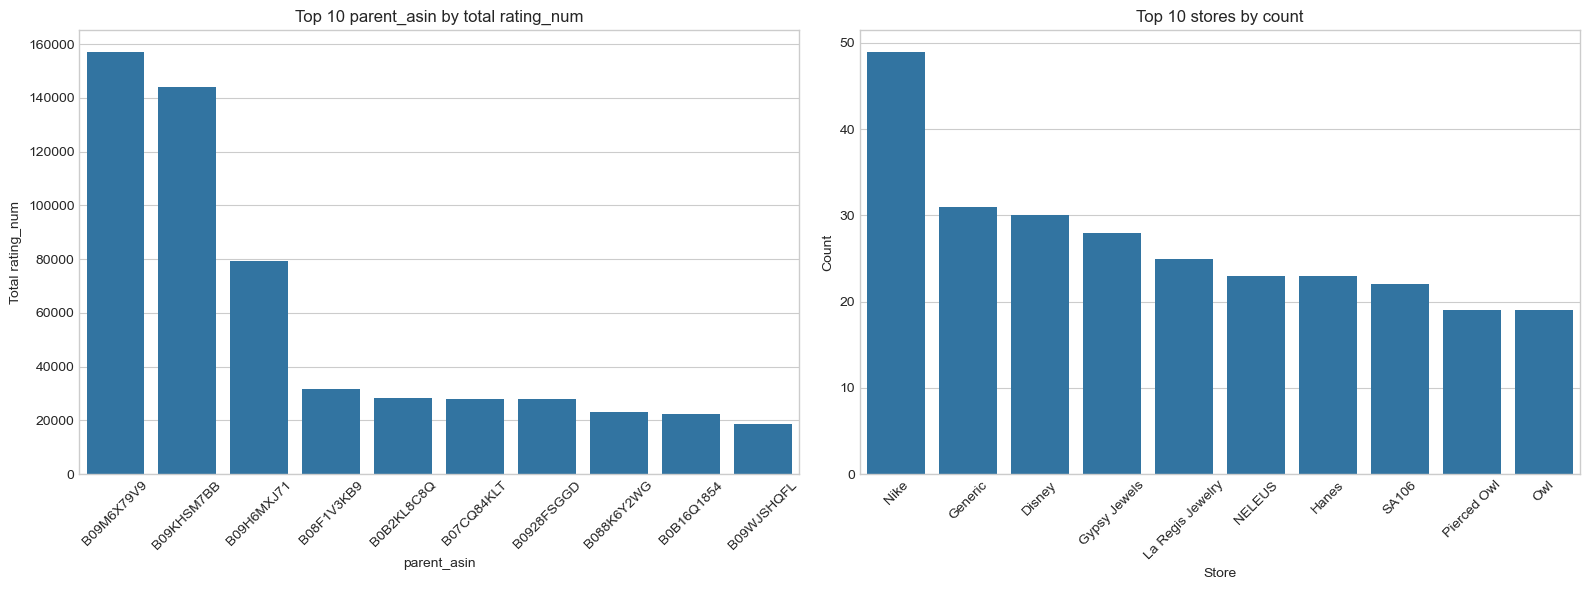

In [73]:
plt.style.use("seaborn-v0_8-whitegrid")

# aggregate rating_num by parent_asin, then get top 10
parent_rating = (
    df.groupby("parent_asin")["rating_num"]
      .sum()                      # use .mean() if you want average instead
      .sort_values(ascending=False)
      .head(10)
)

# still top 10 stores by count
top10_stores = df["store"].value_counts().head(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# left: parent_asin by rating_num sum
sns.barplot(x=parent_rating.index, y=parent_rating.values, ax=axes[0])
axes[0].set_title("Top 10 parent_asin by total rating_num")
axes[0].set_xlabel("parent_asin")
axes[0].set_ylabel("Total rating_num")
axes[0].tick_params(axis="x", rotation=45)

# right: stores by count
sns.barplot(x=top10_stores.index, y=top10_stores.values, ax=axes[1])
axes[1].set_title("Top 10 stores by count")
axes[1].set_xlabel("Store")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

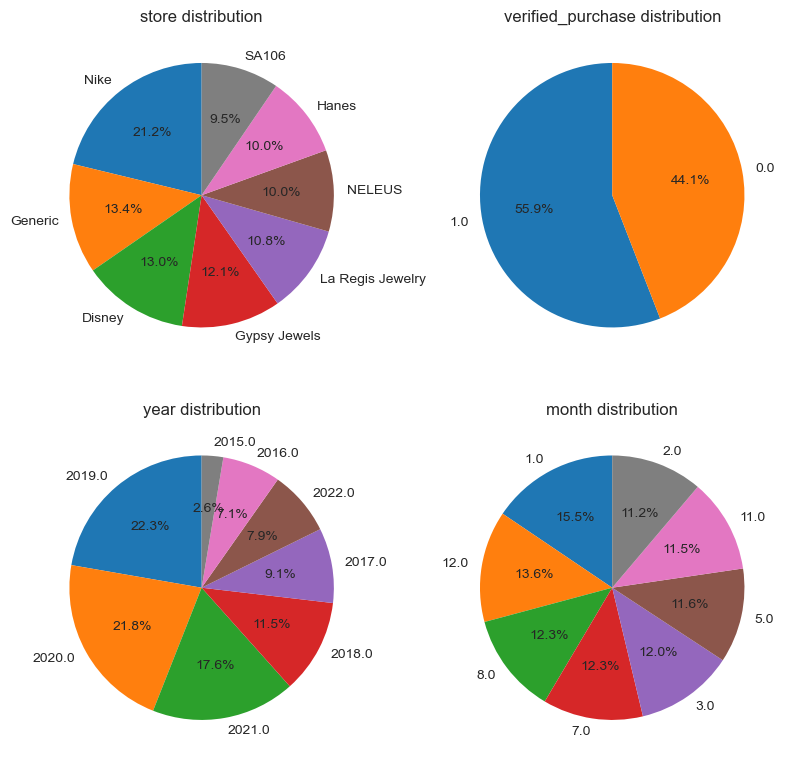

In [74]:
v_cols = ["store", "verified_purchase", "year", "month"]  # pick 4 categorical columns

plt.style.use("seaborn-v0_8-whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(8, 8))
axes = axes.ravel()

for ax, col in zip(axes, v_cols):
    counts = df[col].value_counts().head(8)   # top 8 categories
    ax.pie(
        counts.values,
        labels=counts.index.astype(str),
        autopct="%1.1f%%",
        startangle=90
    )
    ax.set_title(f"{col} distribution")

plt.tight_layout()
plt.show()

#### Boxplot for numeric values

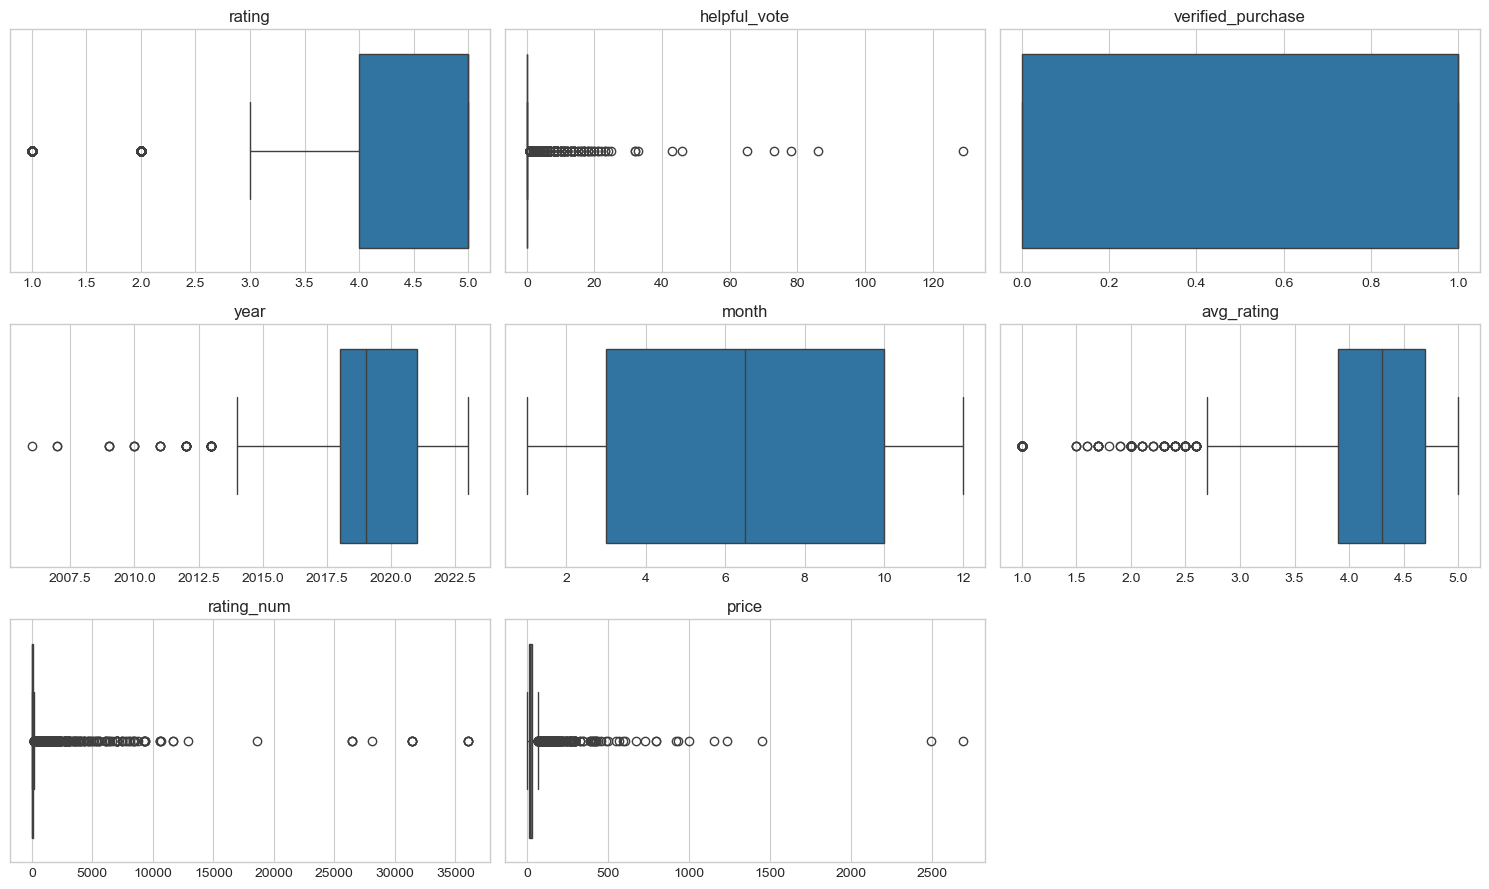

In [75]:
numeric_cols = ['rating', 'helpful_vote', 'verified_purchase',
                'year', 'month', 'avg_rating', 'rating_num', 'price']

ncols = 3
nrows = (len(numeric_cols) + ncols - 1) // ncols

fig, axes = plt.subplots(nrows=nrows, ncols=ncols,
                         figsize=(5 * ncols, 3 * nrows))
axes = axes.flatten()

for ax, col in zip(axes, numeric_cols):
    sns.boxplot(x=df[col].dropna(), ax=ax)
    ax.set_title(col)
    ax.set_xlabel("")

# remove unused axes
for ax in axes[len(numeric_cols):]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()


#### Outlier handling

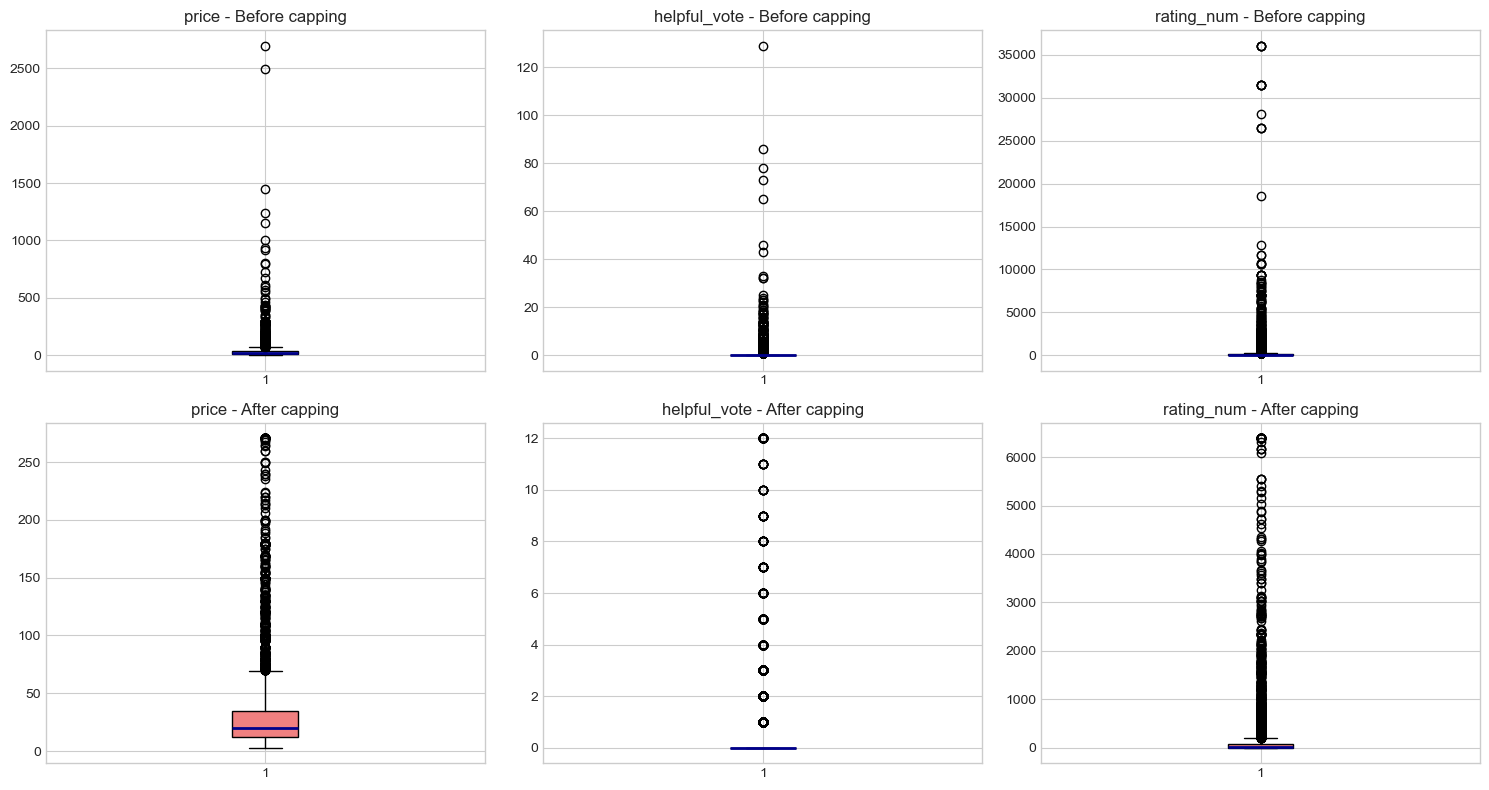

In [76]:
#capping

plt.style.use("seaborn-v0_8-whitegrid")

cols_to_cap = ["price", "helpful_vote", "rating_num"]

# --- capping (if not already done) ---
def cap_series(s, lower=0.01, upper=0.99):
    low_q, high_q = s.quantile([lower, upper])
    return s.clip(lower=low_q, upper=high_q)

df_capped = df.copy()
for col in cols_to_cap:
    df_capped[col] = cap_series(df_capped[col])

# --- boxplots before vs after capping ---
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for i, col in enumerate(cols_to_cap):
    # before capping
    axes[0, i].boxplot(
        df[col].dropna(),
        vert=True,
        patch_artist=True,
        boxprops=dict(facecolor="lightblue", color="black"),
        medianprops=dict(color="darkblue", linewidth=2),
    )
    axes[0, i].set_title(f"{col} - Before capping")

    # after capping
    axes[1, i].boxplot(
        df_capped[col].dropna(),
        vert=True,
        patch_artist=True,
        boxprops=dict(facecolor="lightcoral", color="black"),
        medianprops=dict(color="darkblue", linewidth=2),
    )
    axes[1, i].set_title(f"{col} - After capping")

plt.tight_layout()
plt.show()


But this will cause havoc on the integrity of the dataset so we will not be doing these although dropping extreme values in price would be beneficial for some analysis.

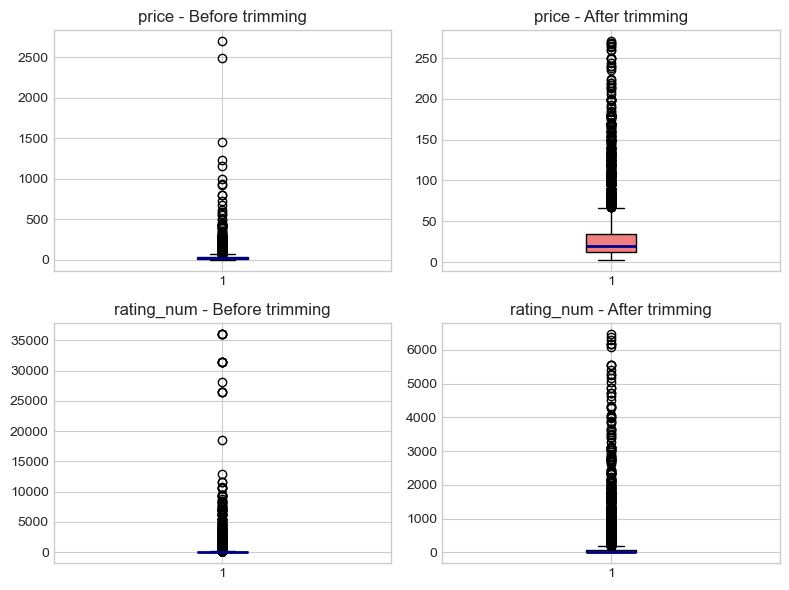

In [77]:
plt.style.use("seaborn-v0_8-whitegrid")

df_trimmed = df.copy()

# --- trim price ---
p_low, p_high = df_trimmed["price"].quantile([0.01, 0.99])
df_trimmed = df_trimmed[(df_trimmed["price"] >= p_low) & (df_trimmed["price"] <= p_high)]

# --- trim rating_num ---
r_low, r_high = df_trimmed["rating_num"].quantile([0.01, 0.99])
df_trimmed = df_trimmed[
    (df_trimmed["rating_num"] >= r_low) &
    (df_trimmed["rating_num"] <= r_high)
]

fig, axes = plt.subplots(2, 2, figsize=(8, 6))

# price before
axes[0, 0].boxplot(
    df["price"].dropna(),
    vert=True,
    patch_artist=True,
    boxprops=dict(facecolor="lightblue", color="black"),
    medianprops=dict(color="darkblue", linewidth=2),
)
axes[0, 0].set_title("price - Before trimming")

# price after
axes[0, 1].boxplot(
    df_trimmed["price"].dropna(),
    vert=True,
    patch_artist=True,
    boxprops=dict(facecolor="lightcoral", color="black"),
    medianprops=dict(color="darkblue", linewidth=2),
)
axes[0, 1].set_title("price - After trimming")

# rating_num before
axes[1, 0].boxplot(
    df["rating_num"].dropna(),
    vert=True,
    patch_artist=True,
    boxprops=dict(facecolor="lightblue", color="black"),
    medianprops=dict(color="darkblue", linewidth=2),
)
axes[1, 0].set_title("rating_num - Before trimming")

# rating_num after
axes[1, 1].boxplot(
    df_trimmed["rating_num"].dropna(),
    vert=True,
    patch_artist=True,
    boxprops=dict(facecolor="lightcoral", color="black"),
    medianprops=dict(color="darkblue", linewidth=2),
)
axes[1, 1].set_title("rating_num - After trimming")

plt.tight_layout()
plt.show()


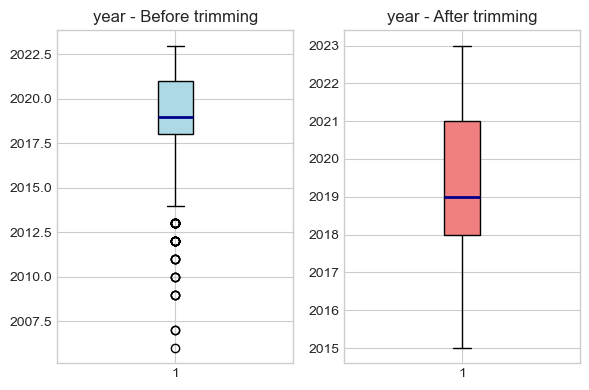

In [78]:
plt.style.use("seaborn-v0_8-whitegrid")

# ensure numeric year
df["year"] = pd.to_numeric(df["year"], errors="coerce")

# choose bounds for valid years
lower_year = 2015
upper_year = 2023

# trimmed dataframe
df_year_trimmed = df[(df["year"] >= lower_year) & (df["year"] <= upper_year)].copy()

fig, axes = plt.subplots(1, 2, figsize=(6, 4))

# year before
axes[0].boxplot(
    df["year"].dropna(),
    vert=True,
    patch_artist=True,
    boxprops=dict(facecolor="lightblue", color="black"),
    medianprops=dict(color="darkblue", linewidth=2),
)
axes[0].set_title("year - Before trimming")

# year after
axes[1].boxplot(
    df_year_trimmed["year"].dropna(),
    vert=True,
    patch_artist=True,
    boxprops=dict(facecolor="lightcoral", color="black"),
    medianprops=dict(color="darkblue", linewidth=2),
)
axes[1].set_title("year - After trimming")

plt.tight_layout()
plt.show()


#### Histogram for numeric values

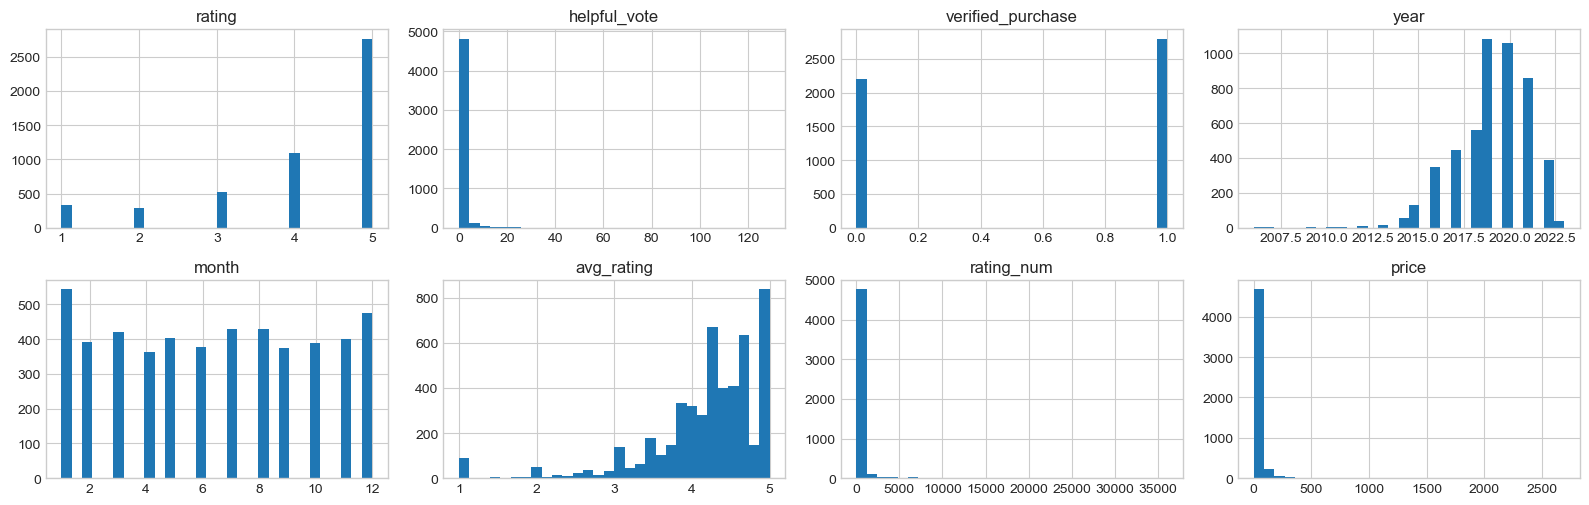

In [79]:
# select only numeric columns
numeric_cols = df.select_dtypes(include=["number"]).columns.tolist()

# histograms for all numeric columns
df[numeric_cols].hist(bins=30, figsize=(16, 10), layout=(4, 4))  # adjust layout to your number of cols
plt.tight_layout()
plt.show()


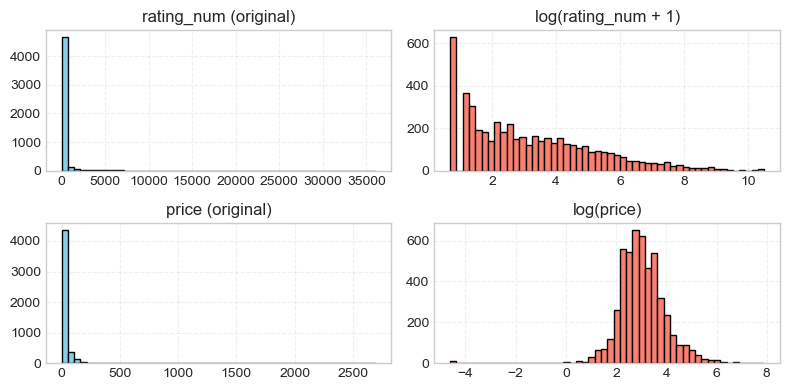

In [80]:
plt.style.use("seaborn-v0_8-whitegrid")

df_trimmed = df.copy()

# log transforms (use log1p for counts to handle zeros)
df_trimmed["log_rating_num"] = np.log1p(df_trimmed["rating_num"])
df_trimmed["log_price"] = np.log(df_trimmed["price"])

fig, axes = plt.subplots(2, 2, figsize=(8, 4))

# rating_num before
axes[0, 0].hist(df_trimmed["rating_num"].dropna(), bins=50, color="skyblue", edgecolor="black")
axes[0, 0].set_title("rating_num (original)")

# log_rating_num after
axes[0, 1].hist(df_trimmed["log_rating_num"].dropna(), bins=50, color="salmon", edgecolor="black")
axes[0, 1].set_title("log(rating_num + 1)")

# price before
axes[1, 0].hist(df_trimmed["price"].dropna(), bins=50, color="skyblue", edgecolor="black")
axes[1, 0].set_title("price (original)")

# log_price after
axes[1, 1].hist(df_trimmed["log_price"].dropna(), bins=50, color="salmon", edgecolor="black")
axes[1, 1].set_title("log(price)")

for ax in axes.flat:
    ax.grid(alpha=0.3, linestyle="--")

plt.tight_layout()
plt.show()


The rating_num on the log scale spreads out across the x‑axis, showing a long right tail and making it easier to see how many products have, say, tens vs hundreds vs thousands of ratings.

price on the original scale again has most products in a low range with a few very expensive ones, which compresses the histogram.

price on the log scale becomes roughly bell‑shaped, suggesting a log‑normal‑like distribution where multiplicative differences (e.g. 2×, 3×) are more meaningful than additive differences.
​

In [81]:
#adding columns
df["log_rating_num"] = np.where(df["rating_num"] > 0,
                                np.log10(df["rating_num"]),
                                np.nan)

df["log_price"] = np.where(df["price"] > 0,
                           np.log10(df["price"]),
                           np.nan)

In [82]:
#verify
df[["rating_num", "log_rating_num", "price", "log_price"]].head()
df[["log_rating_num", "log_price"]].describe()


,log_rating_num,log_price
count,5001.000000,5001.000000
mean,1.289791,1.317743
std,0.948254,0.409074
min,0.000000,-2.000000
25%,0.477121,1.078819
50%,1.146128,1.299943
75%,1.919078,1.541953
max,4.557002,3.430559


# Multivariate Analysis

## RQ 1

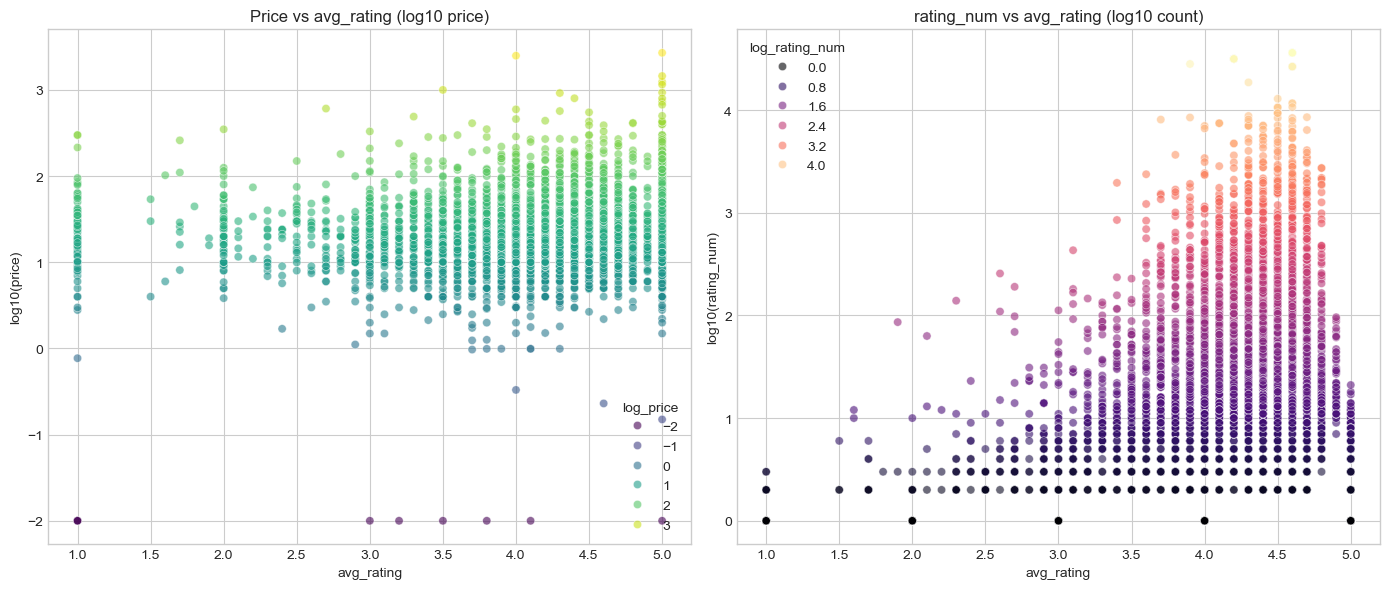

In [83]:
#num vs num col

plt.style.use("seaborn-v0_8-whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.scatterplot(
    data=df,
    x="avg_rating",
    y="log_price",      # <-- no space
    hue="log_price",    # <-- no space
    palette="viridis",
    alpha=0.6,
    ax=axes[0]
)
axes[0].set_title("Price vs avg_rating (log10 price)")
axes[0].set_xlabel("avg_rating")
axes[0].set_ylabel("log10(price)")


# make sure columns have no stray spaces
df.columns = df.columns.str.strip()

# rating_num vs avg_rating (log scale)
sns.scatterplot(
    data=df,
    x="avg_rating",
    y="log_rating_num",      # must exist in df
    hue="log_rating_num",
    palette="magma",
    alpha=0.6,
    ax=axes[1]
)
axes[1].set_title("rating_num vs avg_rating (log10 count)")
axes[1].set_xlabel("avg_rating")
axes[1].set_ylabel("log10(rating_num)")

plt.tight_layout()
plt.show()


The charts say that popular, well‑liked products sit in the middle on price and get far more attention than the rest.

#### Price vs avg_rating

- Shoppers seem happy to give good scores to both cheap and expensive items, so paying more does not automatically buy a better rating.
- Most of the action is around mid‑range prices, where there are lots of products and lots of reviews, while the very cheap and very pricey items are more like niche outliers.

#### rating_num vs avg_rating

- The more people review a product, the more it tends to cluster around 4–5 stars; truly unpopular products almost never go “viral” in terms of review count.
- Low‑rated items usually have just a handful of reviews, which means those bad scores might be more like a few unhappy customers than a clear consensus.


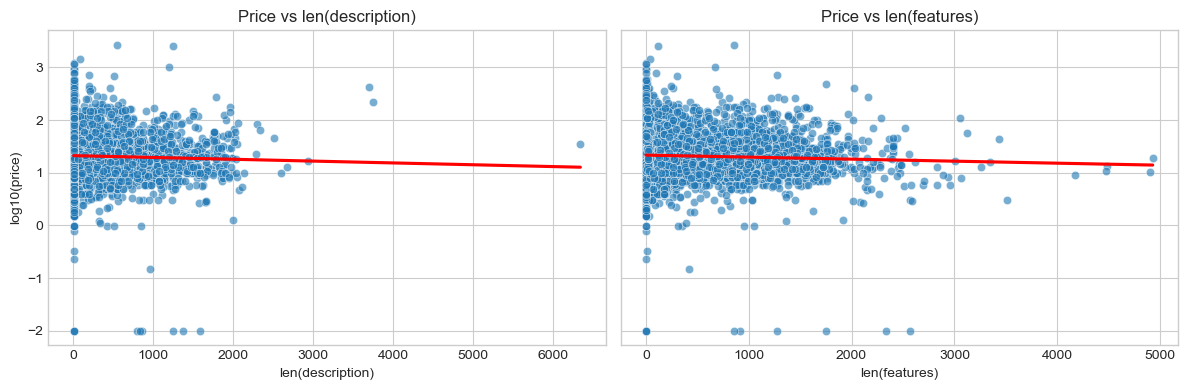

In [84]:
df["desc_len"] = df["description"].str.len()
df["feat_len"] = df["features"].str.len()

plt.style.use("seaborn-v0_8-whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

# 1) price vs len(description)
sns.scatterplot(
    data=df,
    x="desc_len",
    y="log_price",
    alpha=0.6,
    ax=axes[0]
)
sns.regplot(                      # regression line
    data=df,
    x="desc_len",
    y="log_price",
    scatter=False,
    ci=None,
    color="red",
    ax=axes[0]
)
axes[0].set_xlabel("len(description)")
axes[0].set_ylabel("log10(price)")
axes[0].set_title("Price vs len(description)")

# 2) price vs len(features)
sns.scatterplot(
    data=df,
    x="feat_len",
    y="log_price",
    alpha=0.6,
    ax=axes[1]
)
sns.regplot(                      # regression line
    data=df,
    x="feat_len",
    y="log_price",
    scatter=False,
    ci=None,
    color="red",
    ax=axes[1]
)
axes[1].set_xlabel("len(features)")
axes[1].set_ylabel("log10(price)")
axes[1].set_title("Price vs len(features)")

plt.tight_layout()
plt.show()

These lines say that, if anything, longer descriptions and feature lists are associated with *slightly lower* prices, but the effect is tiny.

- In both panels the red regression line tilts gently downward, and the cloud of points stays very wide, so description or feature length explains almost none of the price variation.
- Practically, this means sellers do not charge more just because they wrote more text; cheap and expensive products alike can have either short bullet points or long, detailed write‑ups.


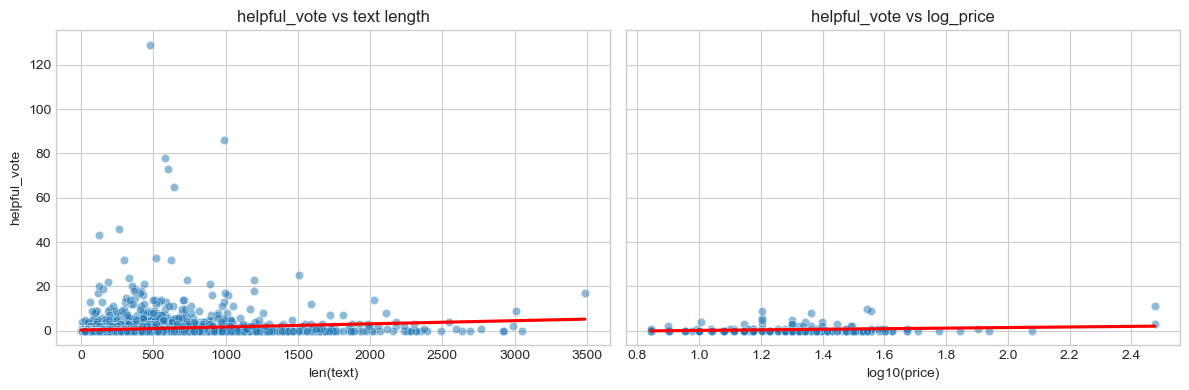

In [62]:
df["text_len"] = df["text"].str.len()

plt.style.use("seaborn-v0_8-whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

# 1) helpful_vote vs text length
sns.scatterplot(
    data=df,
    x="text_len",
    y="helpful_vote",
    alpha=0.5,
    ax=axes[0]
)
sns.regplot(
    data=df,
    x="text_len",
    y="helpful_vote",
    scatter=False,
    ci=None,
    color="red",
    ax=axes[0]
)
axes[0].set_xlabel("len(text)")
axes[0].set_ylabel("helpful_vote")
axes[0].set_title("helpful_vote vs text length")

# 2) helpful_vote vs log_price
sns.scatterplot(
    data=df,
    x="log_price",
    y="helpful_vote",
    alpha=0.5,
    ax=axes[1]
)
sns.regplot(
    data=df,
    x="log_price",
    y="helpful_vote",
    scatter=False,
    ci=None,
    color="red",
    ax=axes[1]
)
axes[1].set_xlabel("log10(price)")
axes[1].set_ylabel("helpful_vote")
axes[1].set_title("helpful_vote vs log_price")

plt.tight_layout()
plt.show()


The plot shows only a very slight tendency for longer reviews to get more helpful votes; most long reviews still receive few or none.

- A large mass of points sits near zero helpful votes across almost all text lengths, meaning “writing more” usually does not guarantee that others find the review helpful.
- A few high‑helpful‑vote outliers occur at moderate lengths (roughly a few hundred characters), suggesting that clarity and content matter more than sheer length for perceived helpfulness.

#### correlation heatmap analysis

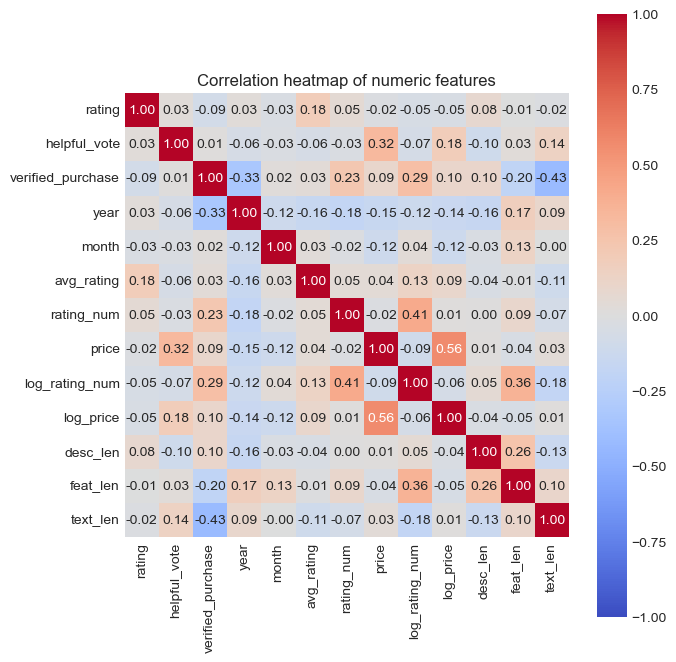

<Figure size 640x480 with 0 Axes>

In [63]:
# numeric columns
numerical_cols = df.select_dtypes(include=["number"]).columns

# correlation matrix
corr = df[numerical_cols].corr()

plt.style.use("seaborn-v0_8-whitegrid")

plt.figure(figsize=(7, 7))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    square=True
)
plt.title("Correlation heatmap of numeric features")
plt.tight_layout()
plt.show()
plt.savefig("my_plot1.png")


This heatmap shows that most numeric features are only weakly correlated, with a few moderate relationships around review volume and text length.

**Strongest patterns**

- **review_len, heading_len, and text_len** are fairly correlated with each other (around 0.6), which is expected since they all measure different parts of the review text.  
- **rating_num and log_rating_num** correlate moderately with **price** and **feat_len**, suggesting more expensive items with richer feature lists tend to attract more ratings, though the correlations are still far from 1.

**Weak/no relationships**

- **rating** and **avg_rating** have only small correlations with other variables, meaning star scores are largely independent of text length, price, and year.  
- **helpful_vote** correlations are close to zero almost everywhere, confirming what the earlier scatterplots showed: helpfulness is noisy and not strongly driven by any single numeric feature.

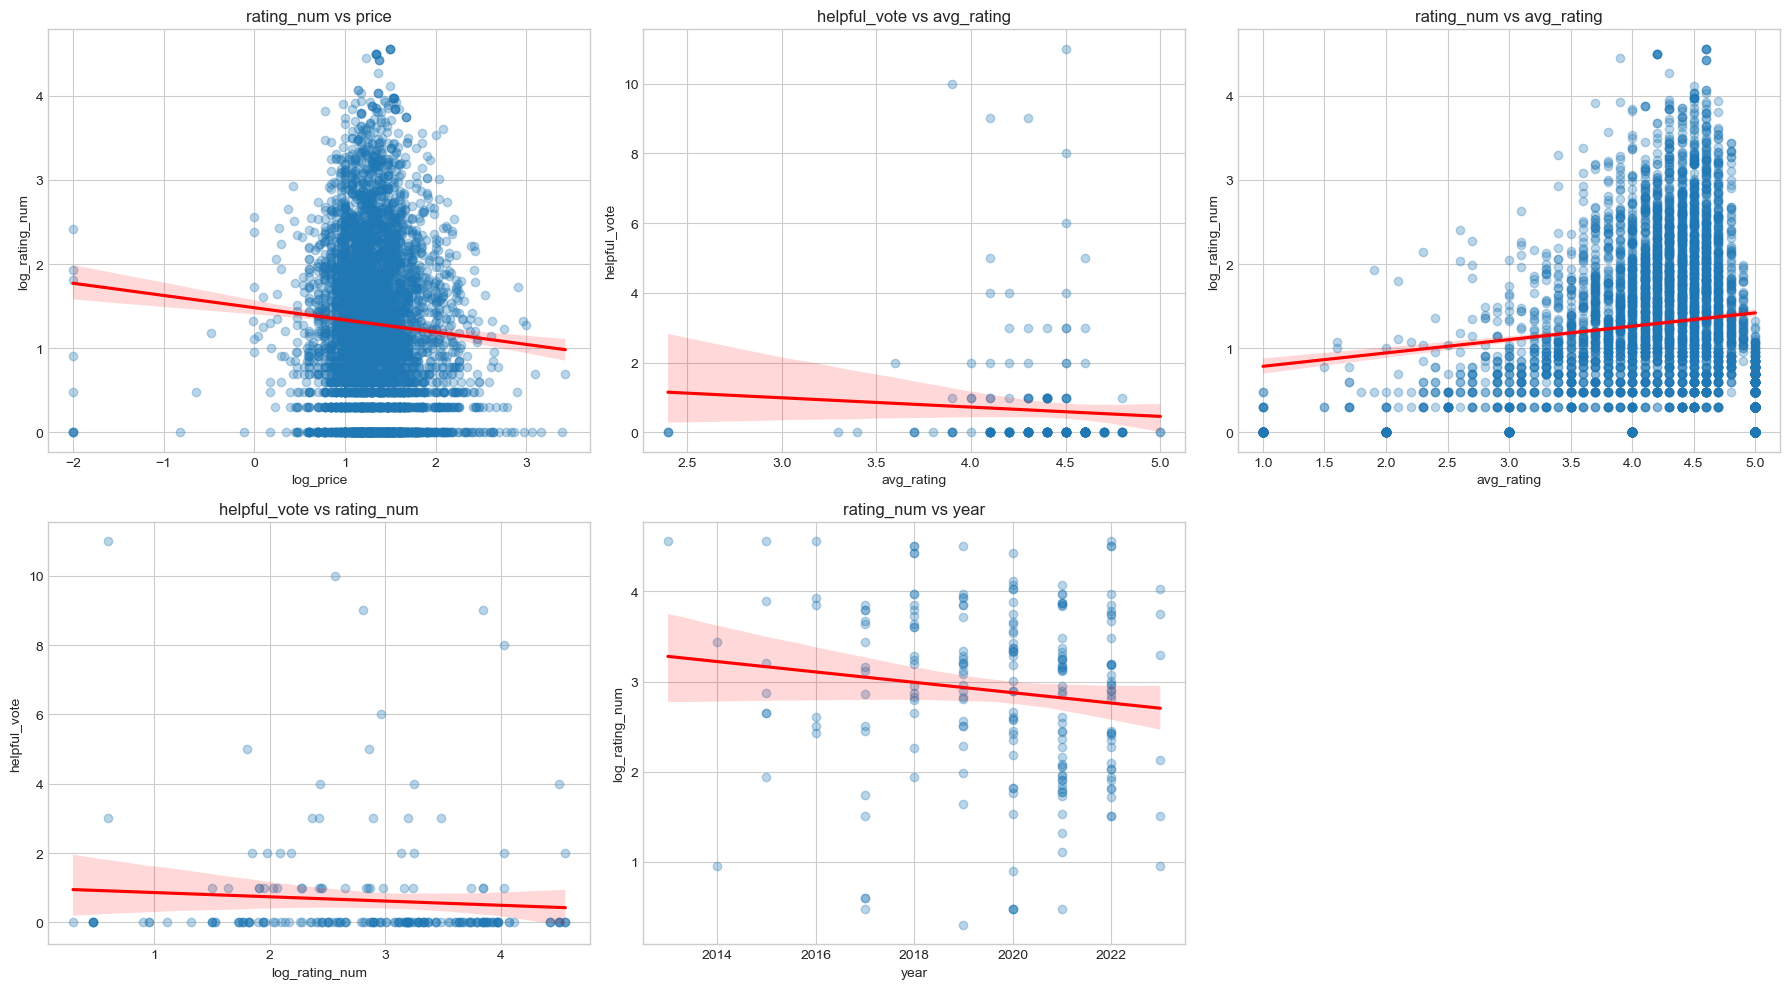

In [85]:
plt.style.use("seaborn-v0_8-whitegrid")

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

# 1. rating_num vs price
sns.regplot(
    data=df, x="log_price", y="log_rating_num",
    ax=axes[0], scatter_kws={"alpha": 0.3}, line_kws={"color": "red"}
)
axes[0].set_title("rating_num vs price")

# 2. avg_rating vs helpful_vote
sns.regplot(
    data=df, x="avg_rating", y="helpful_vote",
    ax=axes[1], scatter_kws={"alpha": 0.3}, line_kws={"color": "red"}
)
axes[1].set_title("helpful_vote vs avg_rating")

# 3. avg_rating vs rating_num
sns.regplot(
    data=df, x="avg_rating", y="log_rating_num",
    ax=axes[2], scatter_kws={"alpha": 0.3}, line_kws={"color": "red"}
)
axes[2].set_title("rating_num vs avg_rating")

# 4. rating_num vs helpful_vote
sns.regplot(
    data=df, x="log_rating_num", y="helpful_vote",
    ax=axes[3], scatter_kws={"alpha": 0.3}, line_kws={"color": "red"}
)
axes[3].set_title("helpful_vote vs rating_num")

# 5. year vs rating_num
sns.regplot(
    data=df, x="year", y="log_rating_num",
    ax=axes[4], scatter_kws={"alpha": 0.3}, line_kws={"color": "red"}
)
axes[4].set_title("rating_num vs year")

# Hide any unused subplot (last one in 2x3 grid)
fig.delaxes(axes[5])

plt.tight_layout()
plt.show()


Taken together, these plots say that popular products tend to be older and better‑rated, while price and “helpfulness” play a much smaller role.

#### rating_num vs log_price

- The regression line slopes gently downward, so very expensive products do not systematically gather more ratings than cheaper or mid‑priced items; price alone is not a strong driver of review volume.

#### helpful_vote vs avg_rating

- Helpful votes stay very low across all avg_rating values, with a slightly negative slope, meaning highly rated products do not necessarily receive more helpful votes on their reviews.

#### rating_num vs avg_rating

- Here the slope is clearly positive: as avg_rating increases, the log of rating count tends to rise, showing that widely reviewed products are typically well liked rather than controversial or heavily down‑rated.

#### helpful_vote vs log_rating_num

- The line is nearly flat: even products with many ratings have reviews that usually get 0–1 helpful votes, so “helpfulness” marks are sparse and not tightly tied to product popularity.

#### rating_num vs year

- The downward trend with year indicates older products (earlier years) tend to accumulate more ratings, which is consistent with having been on the market longer, while newer items have had less time to build up large rating counts.

older products - Products released earlier (smaller year value) tend to have higher rating_num / log_rating_num on the scatterplot, so they have accumulated more ratings over time. Newer products (recent years on the right) rarely reach those very high rating counts, simply because they have not been available long enough for many customers to review them.

#### Description & feature length vs avg_rating

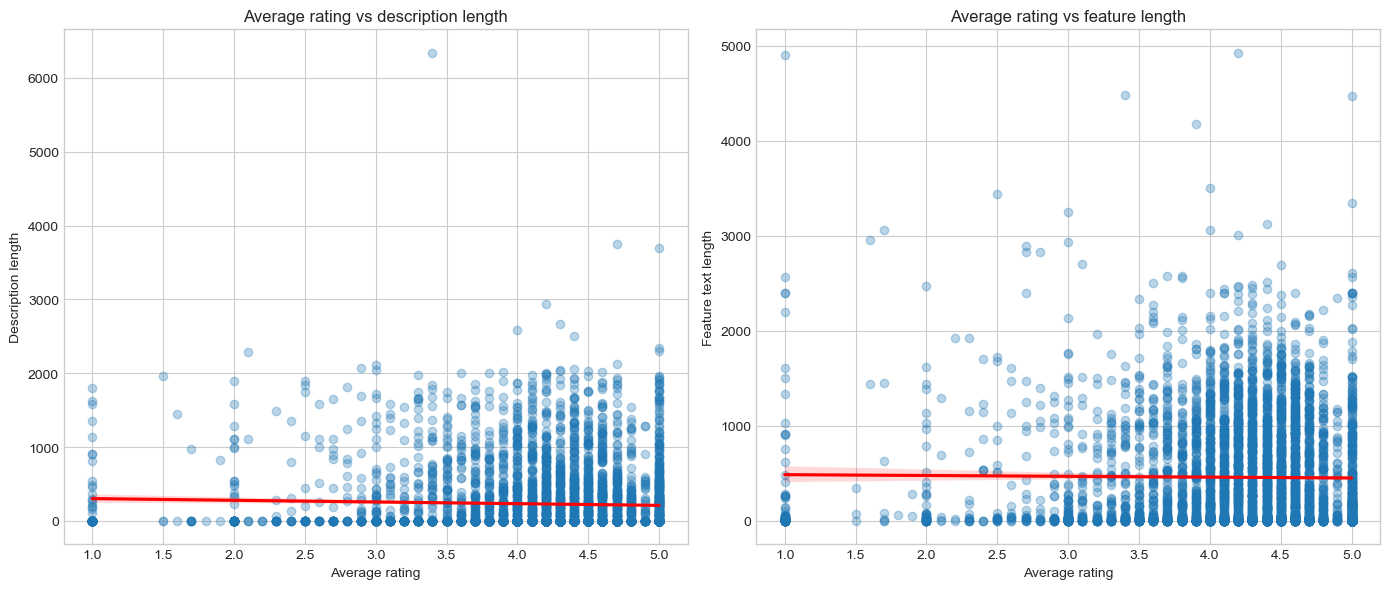

In [86]:
plt.style.use("seaborn-v0_8-whitegrid")

df["desc_len"] = df["description"].fillna("").str.len()
df["feat_len"] = df["features"].fillna("").str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1) avg_rating on x-axis, length on y-axis + regression
sns.regplot(
    data=df,
    x="avg_rating",
    y="desc_len",
    scatter_kws={"alpha": 0.3},
    line_kws={"color": "red"},
    ax=axes[0]
)
axes[0].set_xlabel("Average rating")
axes[0].set_ylabel("Description length")
axes[0].set_title("Average rating vs description length")

sns.regplot(
    data=df,
    x="avg_rating",
    y="feat_len",
    scatter_kws={"alpha": 0.3},
    line_kws={"color": "red"},
    ax=axes[1]
)
axes[1].set_xlabel("Average rating")
axes[1].set_ylabel("Feature text length")
axes[1].set_title("Average rating vs feature length")

plt.tight_layout()
plt.show()


There is a slight pattern that extremely long descriptions/features appear mostly among products with ratings above roughly 3, and higher-priced items (lighter points) are somewhat more common at the longer text lengths, which has a mild association between richer content, higher price, and mid‑to‑high ratings rather than a strong causal effect

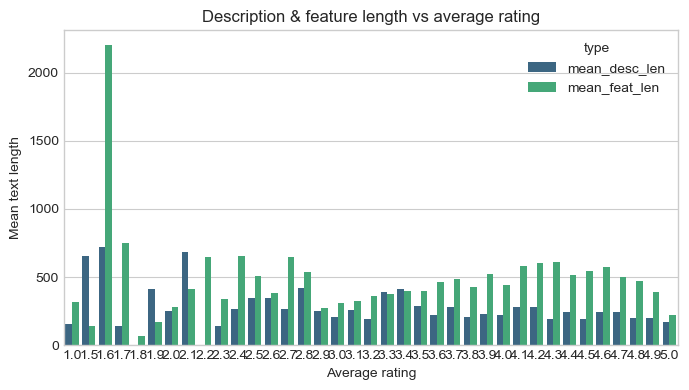

In [87]:
df["desc_len"] = df["description"].fillna("").str.len()
df["feat_len"] = df["features"].fillna("").str.len()

# average lengths per rating
len_by_rating = (
    df.groupby("avg_rating")
      .agg(
          mean_desc_len=("desc_len", "mean"),
          mean_feat_len=("feat_len", "mean")
      )
      .reset_index()
)

plt.style.use("seaborn-v0_8-whitegrid")
plt.figure(figsize=(7, 4))

len_by_rating_melt = len_by_rating.melt(
    id_vars="avg_rating",
    value_vars=["mean_desc_len", "mean_feat_len"],
    var_name="type",
    value_name="mean_length"
)

sns.barplot(
    data=len_by_rating_melt,
    x="avg_rating",
    y="mean_length",
    hue="type",
    palette="viridis"
)

plt.xlabel("Average rating")
plt.ylabel("Mean text length")
plt.title("Description & feature length vs average rating")
plt.tight_layout()
plt.show()


This chart compares how long product descriptions and feature lists are for items with different average ratings. Overall, text is fairly long across the board, and there is no clear upward slope, so writing more does not systematically lead to higher star ratings. A few low‑rated products even have extremely long feature lists, suggesting that very detailed descriptions can still accompany poor customer experiences.


#### 2. Text & heading length vs helpful_vote

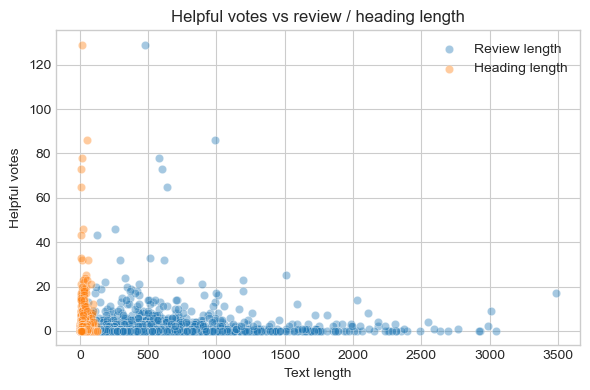

In [88]:
df["review_len"] = df["text"].fillna("").str.len()
df["heading_len"] = df["review_heading"].fillna("").str.len()

plt.style.use("seaborn-v0_8-whitegrid")
plt.figure(figsize=(6, 4))

sns.scatterplot(
    data=df,
    x="review_len",
    y="helpful_vote",
    alpha=0.4,
    color="tab:blue",
    label="Review length"
)

sns.scatterplot(
    data=df,
    x="heading_len",
    y="helpful_vote",
    alpha=0.4,
    color="tab:orange",
    label="Heading length"
)

plt.xlabel("Text length")
plt.ylabel("Helpful votes")
plt.title("Helpful votes vs review / heading length")
plt.legend()
plt.tight_layout()
plt.show()


#### 3. Price-wise total ratings (product performance vs price)


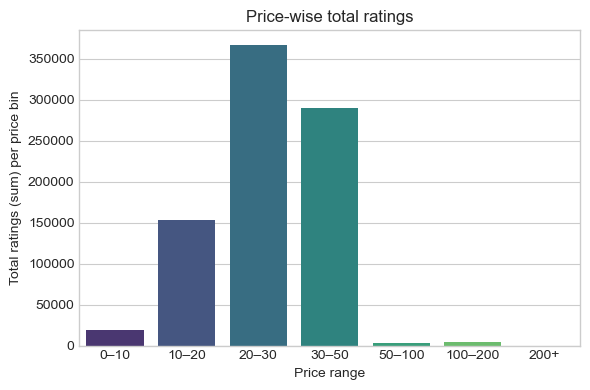

In [107]:
# product-level total ratings and price
prod = (
    df.groupby("asin")
      .agg(
          total_ratings=("rating_num", "sum"),
          price=("price", "first")   # or "median"
      )
      .reset_index()
)

bins = [0, 10, 20, 30, 50, 100, 200, prod["price"].max()]
labels = ["0–10", "10–20", "20–30", "30–50", "50–100", "100–200", "200+"]

prod["price_bin"] = pd.cut(prod["price"], bins=bins, labels=labels, include_lowest=True)

price_totals = (
    prod.groupby("price_bin", observed=False)["total_ratings"]  # or observed=True
        .sum()
        .reset_index()
)

plt.style.use("seaborn-v0_8-whitegrid")
plt.figure(figsize=(6, 4))
sns.barplot(
    data=price_totals,
    x="price_bin",
    y="total_ratings",
    hue="price_bin",
    palette="viridis",
    legend=False,
)

plt.xlabel("Price range")
plt.ylabel("Total ratings (sum) per price bin")
plt.title("Price-wise total ratings")
plt.tight_layout()
plt.show()


## RQ 2

#### Store success

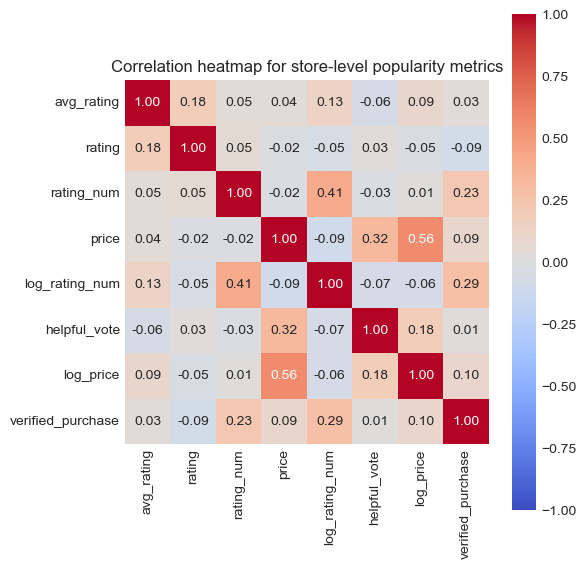

In [90]:
popularity_cols = [
    "avg_rating",
    "rating",          # if you want both overall rating and avg_rating
    "rating_num",
    "price",
    "log_rating_num",
    "helpful_vote",
    "log_price",
    "verified_purchase"
]

# keep only columns that actually exist in df
popularity_cols = [c for c in popularity_cols if c in df.columns]

corr_pop = df[popularity_cols].corr()

plt.style.use("seaborn-v0_8-whitegrid")

plt.figure(figsize=(6, 6))
sns.heatmap(
    corr_pop,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    square=True
)
plt.title("Correlation heatmap for store-level popularity metrics")
plt.tight_layout()
plt.show()


#### Stronger associations

#### log_rating_num and verified_purchase

- This positive correlation suggests that stores/products with more ratings also tend to have more purchases marked as verified, which is a reasonable proxy for genuine customer activity and **real** popularity.
- It supports using **log_rating_num** and **verified_purchase** together as key indicators of store‑level success, since both rise when an item genuinely sells and gets talked about.

#### price and helpful_vote

- The moderate positive link between price and helpful_vote implies reviews on more expensive products receive slightly more “helpful” votes, possibly because shoppers scrutinise costly items more carefully before buying.
- Still, the correlation is not very high, so while price influences how much people rely on helpfulness voting, it is only one of several weaker factors rather than a dominant driver.


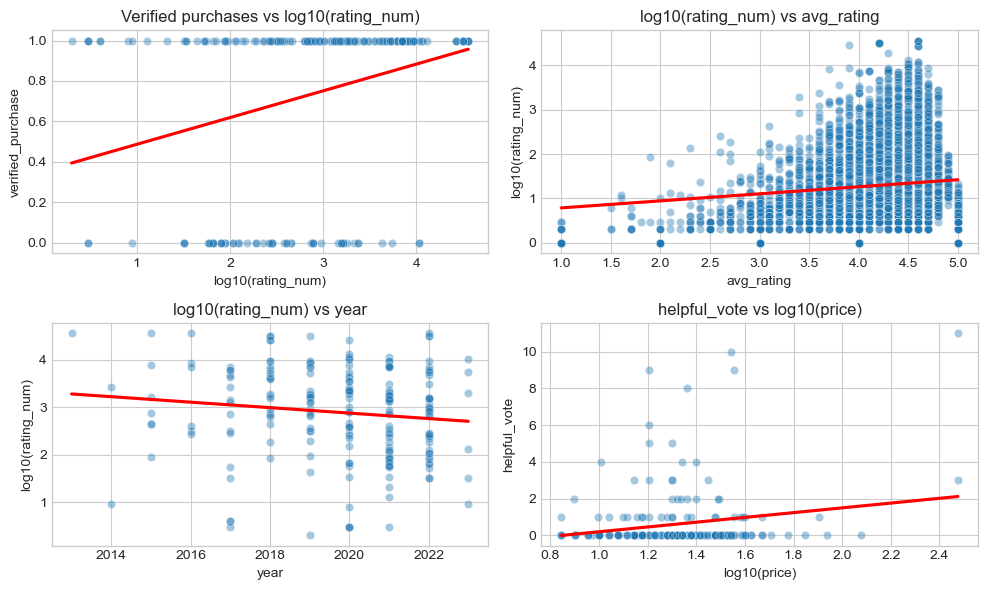

In [91]:
plt.style.use("seaborn-v0_8-whitegrid")

fig, axes = plt.subplots(2, 2, figsize=(10, 6))

# 1) log_rating_num vs verified_purchase
sns.scatterplot(
    data=df,
    x="log_rating_num",
    y="verified_purchase",
    alpha=0.4,
    ax=axes[0, 0]
)
sns.regplot(
    data=df,
    x="log_rating_num",
    y="verified_purchase",
    scatter=False,
    ci=None,
    color="red",
    ax=axes[0, 0]
)
axes[0, 0].set_title("Verified purchases vs log10(rating_num)")
axes[0, 0].set_xlabel("log10(rating_num)")
axes[0, 0].set_ylabel("verified_purchase")

# 2) log_rating_num vs avg_rating
sns.scatterplot(
    data=df,
    x="avg_rating",
    y="log_rating_num",
    alpha=0.4,
    ax=axes[0, 1]
)
sns.regplot(
    data=df,
    x="avg_rating",
    y="log_rating_num",
    scatter=False,
    ci=None,
    color="red",
    ax=axes[0, 1]
)
axes[0, 1].set_title("log10(rating_num) vs avg_rating")
axes[0, 1].set_xlabel("avg_rating")
axes[0, 1].set_ylabel("log10(rating_num)")

# 3) log_rating_num vs year
sns.scatterplot(
    data=df,
    x="year",
    y="log_rating_num",
    alpha=0.4,
    ax=axes[1, 0]
)
sns.regplot(
    data=df,
    x="year",
    y="log_rating_num",
    scatter=False,
    ci=None,
    color="red",
    ax=axes[1, 0]
)
axes[1, 0].set_title("log10(rating_num) vs year")
axes[1, 0].set_xlabel("year")
axes[1, 0].set_ylabel("log10(rating_num)")

# 4) helpful_vote vs log_price
sns.scatterplot(
    data=df,
    x="log_price",
    y="helpful_vote",
    alpha=0.4,
    ax=axes[1, 1]
)
sns.regplot(
    data=df,
    x="log_price",
    y="helpful_vote",
    scatter=False,
    ci=None,
    color="red",
    ax=axes[1, 1]
)
axes[1, 1].set_title("helpful_vote vs log10(price)")
axes[1, 1].set_xlabel("log10(price)")
axes[1, 1].set_ylabel("helpful_vote")

plt.tight_layout()
plt.show()


These four plots together say that real popularity is mostly about having many ratings, which is helped a bit by high average ratings and time on the market, while price and helpful votes play smaller roles.

#### Verified purchases vs log10(rating_num)

- The strong upward red line shows that as log_rating_num increases, the share of verified purchases rises, so heavily rated products are more likely to have genuine, verified buyers behind those ratings.

#### log10(rating_num) vs avg_rating

- The positive slope indicates that items with higher average ratings tend to have more ratings, meaning popular products are typically well liked, not heavily down‑rated.

#### log10(rating_num) vs year

- The downward trend suggests older products (earlier years) generally have more ratings, which fits the idea that they have had more time to accumulate reviews.

#### helpful_vote vs log10(price)

- The slight upward slope shows that reviews on more expensive products receive somewhat more helpful votes, but the effect is modest and most reviews still get 0–1 vote regardless of price.



#### store popularity

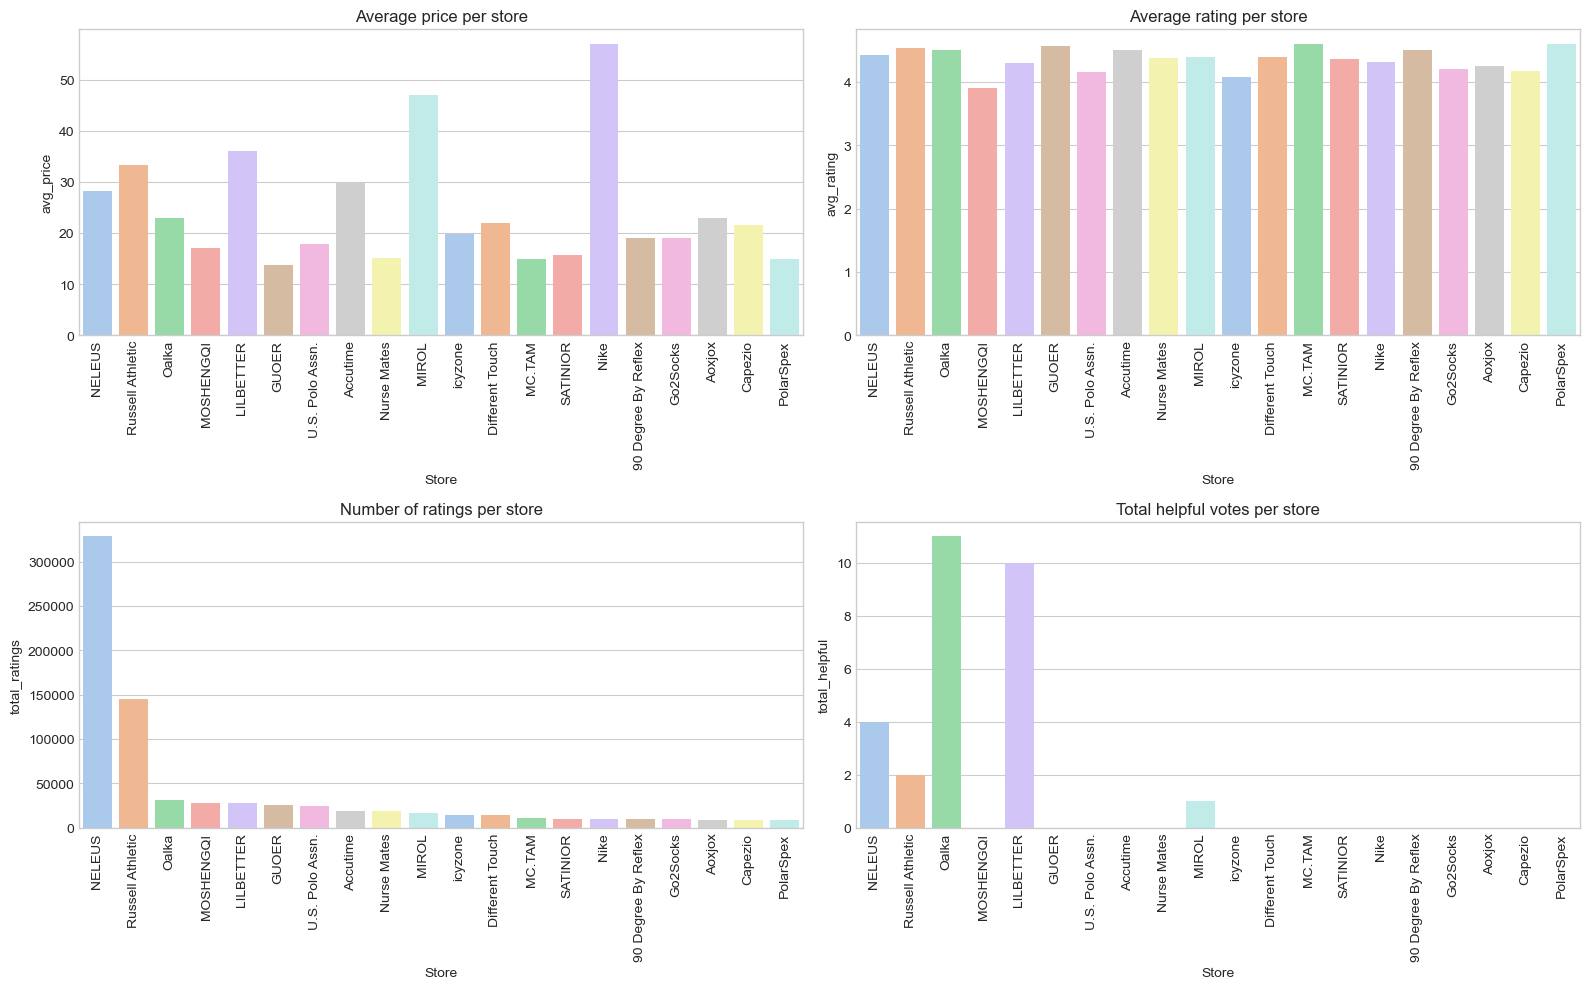

In [77]:
plt.style.use("seaborn-v0_8-whitegrid")

store_perf = (
    df.groupby("store")
      .agg(
          avg_price=("price", "mean"),
          avg_rating=("avg_rating", "mean"),
          total_ratings=("rating_num", "sum"),
          total_helpful=("helpful_vote", "sum")
      )
      .reset_index()
)

topN = 20
store_perf = store_perf.sort_values("total_ratings", ascending=False).head(topN)

# make palette with at least topN colors
palette = sns.color_palette("pastel", n_colors=len(store_perf))

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

# 1) avg_price
sns.barplot(
    data=store_perf,
    x="store",
    y="avg_price",
    hue="store",          # optional hue; remove if you don't need it
    dodge=False,
    palette=palette,
    ax=axes[0]
)
axes[0].set_title("Average price per store")

# 2) avg_rating
sns.barplot(
    data=store_perf,
    x="store",
    y="avg_rating",
    hue="store",
    dodge=False,
    palette=palette,
    ax=axes[1]
)
axes[1].set_title("Average rating per store")

# 3) total_ratings
sns.barplot(
    data=store_perf,
    x="store",
    y="total_ratings",
    hue="store",
    dodge=False,
    palette=palette,
    ax=axes[2]
)
axes[2].set_title("Number of ratings per store")

# 4) total_helpful
sns.barplot(
    data=store_perf,
    x="store",
    y="total_helpful",
    hue="store",
    dodge=False,
    palette=palette,
    ax=axes[3]
)
axes[3].set_title("Total helpful votes per store")

for ax in axes:
    ax.set_xlabel("Store")
    ax.tick_params(axis="x", rotation=90)
    # legend is redundant when hue==x
    if ax.get_legend() is not None:
        ax.get_legend().remove()

plt.tight_layout()
plt.show()


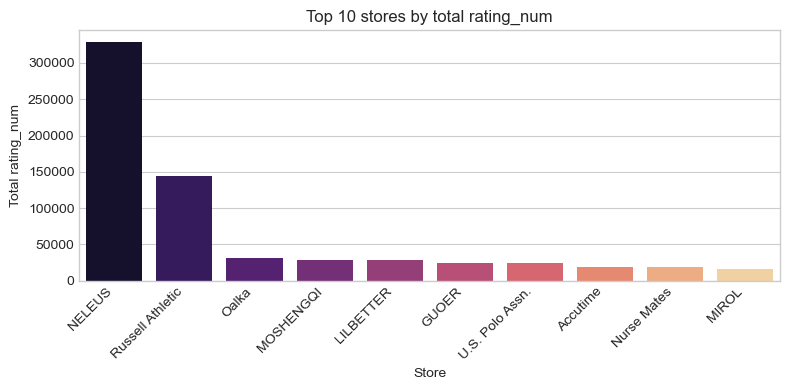

In [92]:
# sum of rating_num per store
store_ratings = (
    df.groupby("store")["rating_num"]
      .sum()
      .reset_index(name="total_rating_num")
)

# keep only top 10 stores by total_rating_num
top10 = store_ratings.nlargest(10, "total_rating_num")

plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots(figsize=(8, 4))

sns.barplot(
    data=top10,
    x="store",
    y="total_rating_num",
    hue="store",
    palette="magma",
    legend=False,
    ax=ax
)

ax.set_xticks(range(len(top10["store"])))
ax.set_xticklabels(top10["store"], rotation=45, ha="right")
ax.set_xlabel("Store")
ax.set_ylabel("Total rating_num")
ax.set_title("Top 10 stores by total rating_num")

fig.tight_layout()
plt.show()


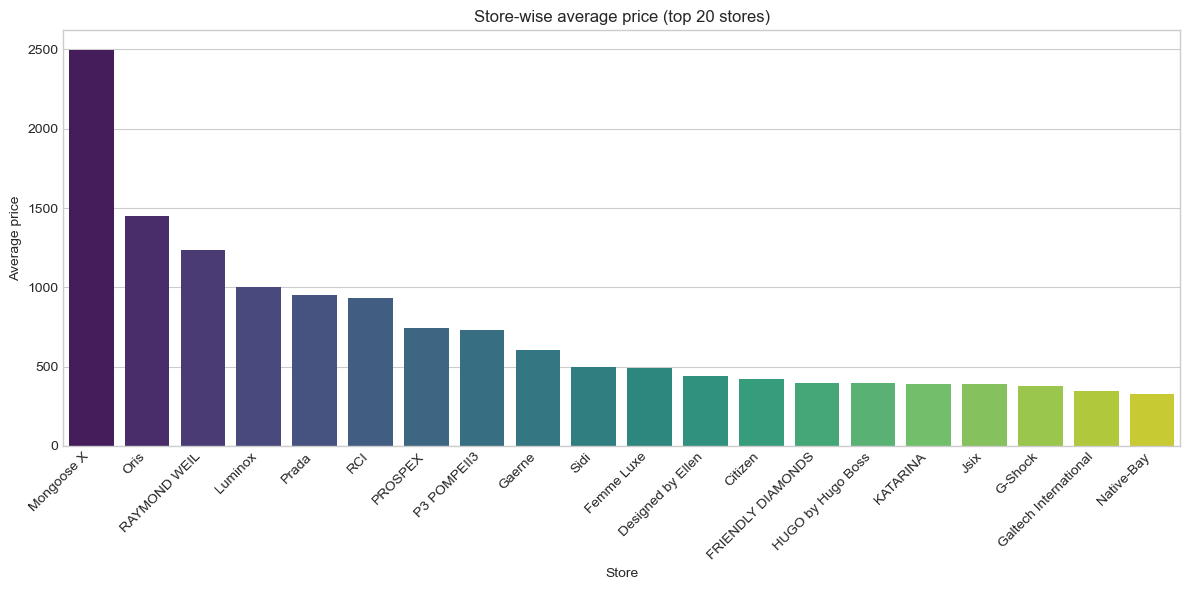

In [79]:
plt.style.use("seaborn-v0_8-whitegrid")

store_avg_price = (
    df.groupby("store", as_index=False)["price"]
      .mean()
      .rename(columns={"price": "avg_price"})
)

store_avg_price = store_avg_price.sort_values("avg_price", ascending=False).head(20)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=store_avg_price,
    x="store",
    y="avg_price",
    hue="store",        # assign hue
    palette="viridis",
    dodge=False,
    legend=False        # same colors, no redundant legend
)
plt.xticks(rotation=45, ha="right")
plt.xlabel("Store")
plt.ylabel("Average price")
plt.title("Store-wise average price (top 20 stores)")
plt.tight_layout()
plt.show()


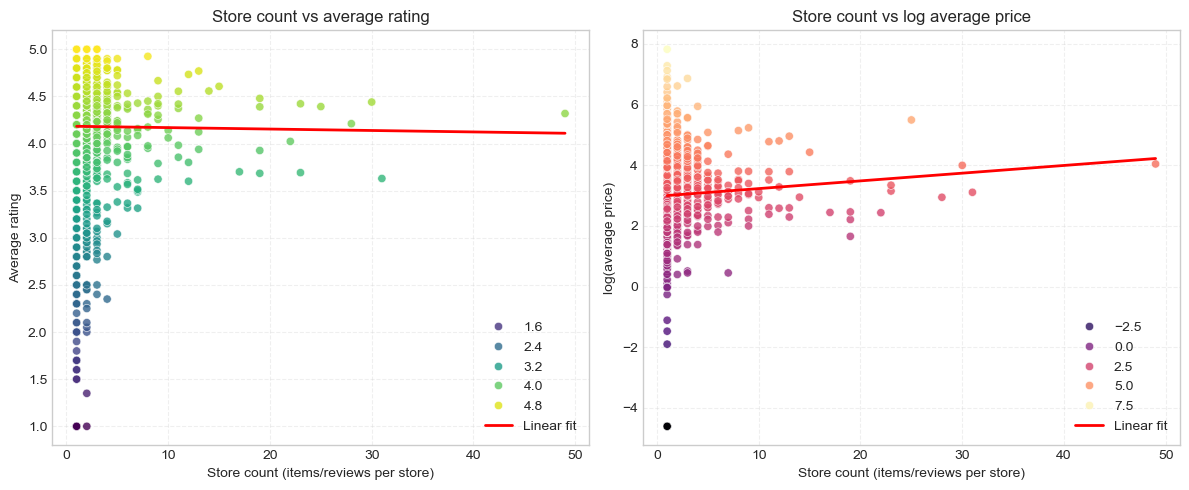

In [93]:
plt.style.use("seaborn-v0_8-whitegrid")

store_stats = (
    df_trimmed.groupby("store")
      .agg(
          store_count=("store", "size"),
          avg_rating=("avg_rating", "mean"),
          avg_price=("price", "mean")
      )
      .reset_index()
)

# log-transform avg_price (use log1p if zeros possible)
store_stats["log_price"] = np.log(store_stats["avg_price"])   # or np.log1p(...)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True)
ax1, ax2 = axes

# --- 1) store count vs avg rating ---
sns.scatterplot(
    data=store_stats,
    x="store_count",
    y="avg_rating",
    hue="avg_rating",
    palette="viridis",
    alpha=0.8,
    ax=ax1
)

x = store_stats["store_count"].to_numpy()
y_rating = store_stats["avg_rating"].to_numpy()
m1, b1 = np.polyfit(x, y_rating, 1)
xx = np.linspace(x.min(), x.max(), 200)
ax1.plot(xx, m1*xx + b1, color="red", linewidth=2, label="Linear fit")

ax1.set_xlabel("Store count (items/reviews per store)")
ax1.set_ylabel("Average rating")
ax1.set_title("Store count vs average rating")
ax1.grid(alpha=0.3, linestyle="--")
ax1.legend()

# --- 2) store count vs log(avg price) ---
sns.scatterplot(
    data=store_stats,
    x="store_count",
    y="log_price",
    hue="log_price",
    palette="magma",
    alpha=0.8,
    ax=ax2
)

y_logp = store_stats["log_price"].to_numpy()
m2, b2 = np.polyfit(x, y_logp, 1)
ax2.plot(xx, m2*xx + b2, color="red", linewidth=2, label="Linear fit")

ax2.set_xlabel("Store count (items/reviews per store)")
ax2.set_ylabel("log(average price)")
ax2.set_title("Store count vs log average price")
ax2.grid(alpha=0.3, linestyle="--")
ax2.legend()

plt.tight_layout()
plt.show()


#### count vs average rating

The red line is a linear fit; its slight downward slope means larger stores tend to have marginally lower ratings on average, but the relationship is weak because points are widely scattered.

#### count vs log average price

The red line slopes upward, suggesting that stores with more items/reviews tend to charge higher prices on average, and the spread of points shows there is still a lot of variability around that trend

#### SEASONALITY

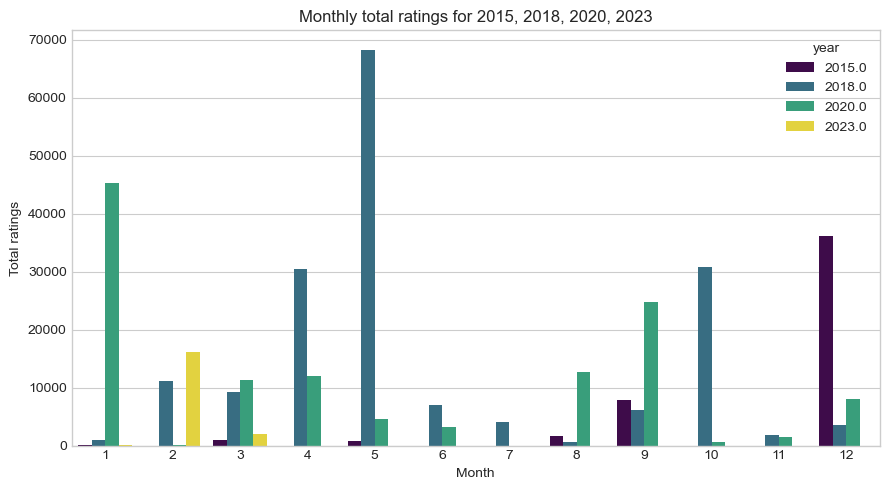

In [108]:
# ensure datetime, year, month
df["review_date"] = pd.to_datetime(df["review_date"])
df["year"] = df["review_date"].dt.year
df["month"] = df["review_date"].dt.month

# total rating_num per year-month
ym = (
    df.groupby(["year", "month"])["rating_num"]
      .sum()
      .reset_index(name="total_rating_num")
)

# keep only selected years
years_of_interest = [2015, 2018, 2020, 2023]
ym_sel = ym[ym["year"].isin(years_of_interest)]

plt.style.use("seaborn-v0_8-whitegrid")
plt.figure(figsize=(9, 5))

sns.barplot(
    data=ym_sel,
    x="month",
    y="total_rating_num",
    hue="year",
    palette="viridis"
)

plt.xticks(range(0, 12), range(1, 13))
plt.xlabel("Month")
plt.ylabel("Total ratings")
plt.title("Monthly total ratings for 2015, 2018, 2020, 2023")
plt.tight_layout()
plt.show()


Across years, early-year months (Jan–Mar) and late-year months (Oct–Dec) tend to have higher bars when data exists, hinting at seasonality where shopping and review activity cluster around winter and possibly promotional periods

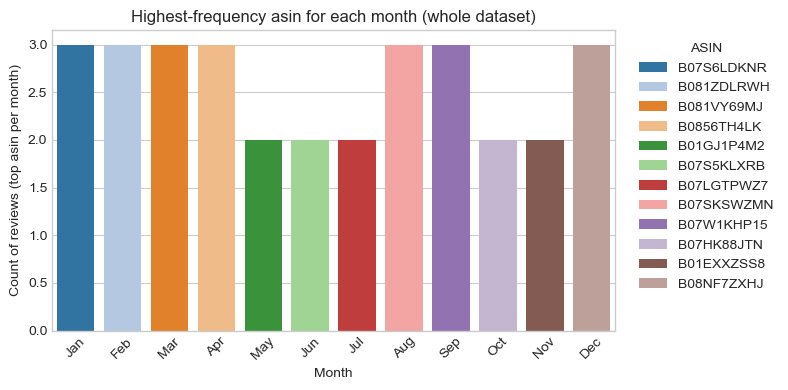

In [96]:
plt.style.use("seaborn-v0_8-whitegrid")

# ensure month exists
#df["review_date"] = pd.to_datetime(df["review_date"])
#df["month"] = df["review_date"].dt.month

# frequency of asin per month
vc = (
    df.groupby("month")["asin"]
      .value_counts()
      .rename("count")
      .reset_index()
)

# keep highest-count asin per month
idx = vc.groupby("month")["count"].idxmax()
top_asin_month = vc.loc[idx].sort_values("month")

month_labels = ["Jan","Feb","Mar","Apr","May","Jun",
                "Jul","Aug","Sep","Oct","Nov","Dec"]

plt.figure(figsize=(8, 4))
sns.barplot(
    data=top_asin_month,
    x="month",
    y="count",
    hue="asin",
    dodge=False,
    palette="tab20"
)

plt.xticks(ticks=range(len(month_labels)), labels=month_labels, rotation=45)
plt.xlabel("Month")
plt.ylabel("Count of reviews (top asin per month)")
plt.title("Highest-frequency asin for each month (whole dataset)")
plt.legend(title="ASIN", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


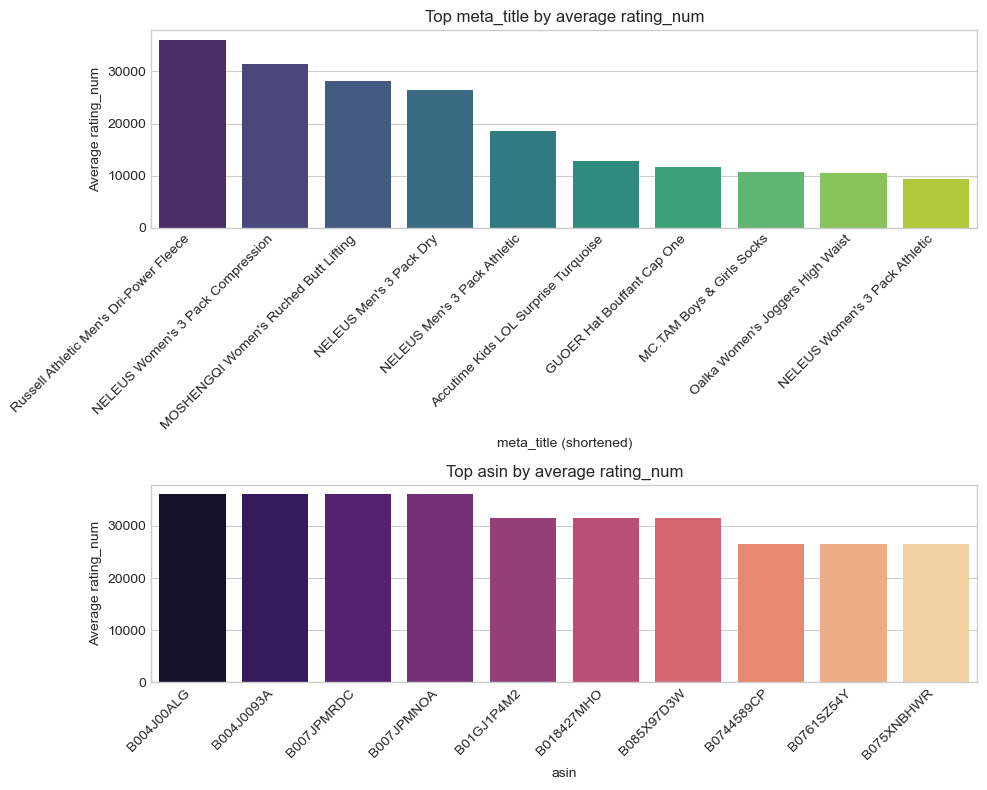

In [99]:
plt.style.use("seaborn-v0_8-whitegrid")

# --- data prep (same as before for meta_title) ---
title_stats = (
    df.groupby("meta_title")["rating_num"]
      .mean()
      .reset_index(name="avg_rating_num")
)
top_titles = title_stats.sort_values("avg_rating_num", ascending=False).head(10).copy()

def short_label(s, max_chars=200, max_words=5):
    words = str(s).split()
    label = " ".join(words[:max_words])
    return (label[:max_chars] + "…") if len(label) > max_chars else label

top_titles["label"] = top_titles["meta_title"].apply(short_label)

# --- prepare asin stats with same y variable ---
asin_stats = (
    df.groupby("asin")["rating_num"]
      .mean()
      .reset_index(name="avg_rating_num")
)
top_asin = asin_stats.sort_values("avg_rating_num", ascending=False).head(10)

# --- subplots 2 x 1 ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharey=True)

# subplot 1: meta_title
sns.barplot(
    data=top_titles,
    x="label",
    y="avg_rating_num",
    hue="label",           # <- use hue to color bars
    palette="viridis",
    dodge=False,
    legend=False,
    ax=ax1
)
plt.setp(ax1.get_xticklabels(), rotation=45, ha="right")
ax1.set_xlabel("meta_title (shortened)")
ax1.set_ylabel("Average rating_num")
ax1.set_title("Top meta_title by average rating_num")

# subplot 2: asin
sns.barplot(
    data=top_asin,
    x="asin",
    y="avg_rating_num",
    hue="asin",            # <- use hue to color bars
    palette="magma",
    dodge=False,
    legend=False,
    ax=ax2
)
plt.setp(ax2.get_xticklabels(), rotation=45, ha="right")
ax2.set_xlabel("asin")
ax2.set_ylabel("Average rating_num")
ax2.set_title("Top asin by average rating_num")

plt.tight_layout()
plt.show()


# Temporal Analysis

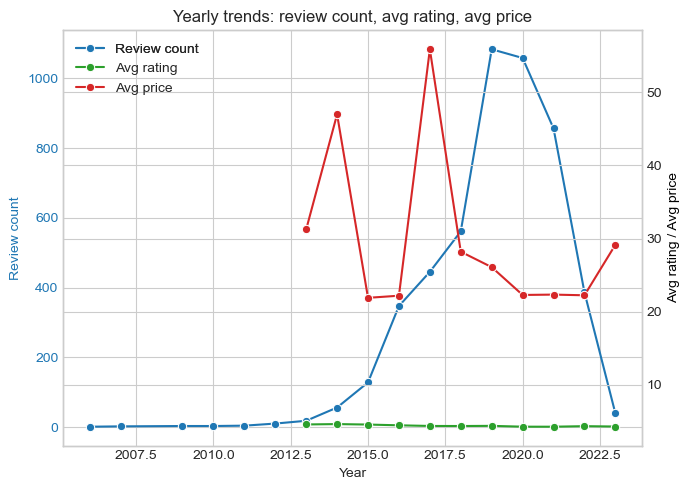

In [110]:
plt.style.use("seaborn-v0_8-whitegrid")

# 1) aggregate
reviews_per_year = df.groupby("year").size().reset_index(name="review_count")
avg_rating_year   = df.groupby("year")["avg_rating"].mean().reset_index()
avg_price_year    = df.groupby("year")["price"].mean().reset_index()

fig, ax1 = plt.subplots(figsize=(7, 5))

# reviews (left y-axis)
sns.lineplot(data=reviews_per_year, x="year", y="review_count",
             marker="o", color="tab:blue", label="Review count", ax=ax1)
ax1.set_xlabel("Year")
ax1.set_ylabel("Review count", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")

# second y-axis for rating & price
ax2 = ax1.twinx()

sns.lineplot(data=avg_rating_year, x="year", y="avg_rating",
             marker="o", color="tab:green", label="Avg rating", ax=ax2)
sns.lineplot(data=avg_price_year, x="year", y="price",
             marker="o", color="tab:red", label="Avg price", ax=ax2)

ax2.set_ylabel("Avg rating / Avg price", color="black")

# combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.title("Yearly trends: review count, avg rating, avg price")
plt.tight_layout()
plt.show()


This figure shows how overall popularity and pricing evolve by year. 

- Review counts rise sharply from around 2014, peak around 2019–2020, and then fall back, suggesting a boom and subsequent slowdown in fashion review activity. Average ratings stay fairly flat across years, so more reviews do not necessarily change how positively products are judged.

- Average prices move around more, but there is no clear long‑run upward or downward trend, implying that shifts in demand are driven more by how much people review than by big price changes.


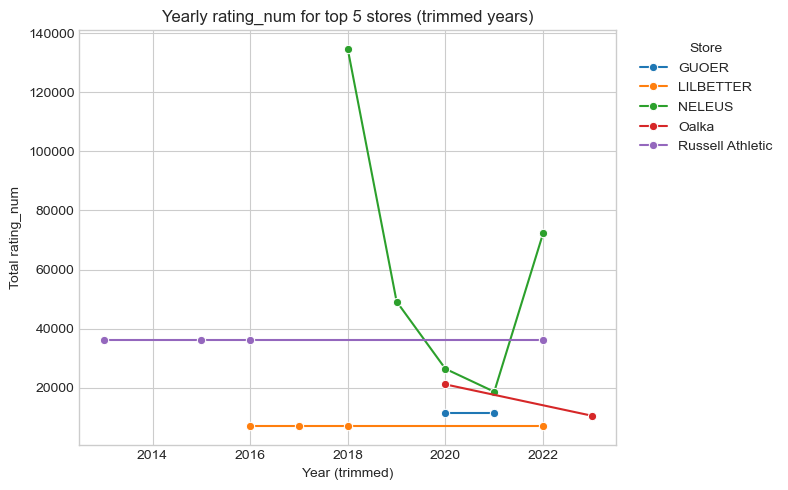

In [86]:
plt.style.use("seaborn-v0_8-whitegrid")

# 1) top 5 stores by total rating_num in trimmed data
store_totals = (
    df_trimmed.groupby("store")["rating_num"]
              .sum()
              .reset_index()
)

top5_stores = store_totals.nlargest(6, "rating_num")["store"]

# 2) yearly rating_num for those stores (trimmed years only)
top5_yearly = (
    df_trimmed[df_trimmed["store"].isin(top5_stores)]
      .groupby(["store", "year"])["rating_num"]
      .sum()
      .reset_index()
)

# 3) line plot: rating_num over trimmed years
plt.figure(figsize=(8, 5))
sns.lineplot(
    data=top5_yearly,
    x="year",
    y="rating_num",
    hue="store",
    marker="o"
)

plt.xlabel("Year (trimmed)")
plt.ylabel("Total rating_num")
plt.title("Yearly rating_num for top 5 stores (trimmed years)")
plt.legend(title="Store", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


 In terms of Research Question 2, this indicates that sustained store‑level success is rare. Russell Athletic manages it, whereas other brands either peak briefly (NELEUS) or gradually lose visibility.
 
- This plot shows yearly total ratings for the top five stores, capturing how their popularity evolves over time. Russell Athletic is remarkably stable, maintaining around 36,000 ratings each year, which points to steady, long‑term success. NELEUS is more volatile: it spikes very high in 2019, drops in 2020–2021, then recovers in 2022, suggesting popularity that comes in waves rather than being constant.

- GUOER, LILBETTER, and Oalka remain at much lower levels, with Oalka’s ratings clearly declining over time. 

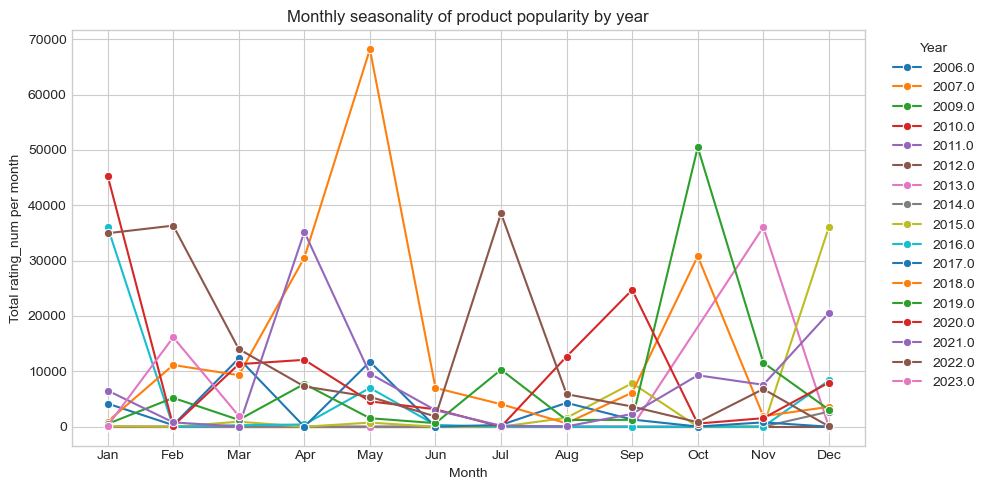

In [97]:
plt.style.use("seaborn-v0_8-whitegrid")

#df["review_date"] = pd.to_datetime(df["review_date"])
#df["year"] = df["review_date"].dt.year
#df["month"] = df["review_date"].dt.month

monthly_pop = (
    df.groupby(["year", "month"])["rating_num"]
      .sum()
      .reset_index()
)

month_labels = ["Jan","Feb","Mar","Apr","May","Jun","Jul",
                "Aug","Sep","Oct","Nov","Dec"]

# build a palette with as many colors as years
years = sorted(monthly_pop["year"].unique())
palette = sns.color_palette("tab10", n_colors=len(years))  # or "bright", "colorblind", etc.

plt.figure(figsize=(10, 5))
sns.lineplot(
    data=monthly_pop,
    x="month",
    y="rating_num",
    hue="year",
    palette=palette,
    marker="o"
)

plt.xticks(ticks=range(1, 13), labels=month_labels)
plt.xlabel("Month")
plt.ylabel("Total rating_num per month")
plt.title("Monthly seasonality of product popularity by year")
plt.legend(title="Year", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


This line plot relates to Research Question 3, tracks how popular the products are in each month of the year, using total rating counts as a proxy for popularity. 

- A few clear spikes stand out: for several years there are sharp jumps around May, October, and November, while other months stay relatively low. That pattern suggests shoppers pay much more attention to these fashion items in specific seasons, likely around spring and late‑year/holiday periods, rather than spreading their interest evenly across the year.

- At the same time, the exact timing and height of the peaks change from year to year, which means the seasonal effect is real but not perfectly stable. This shows that product demand clusters in particular months but can still shift in intensity and timing across different years


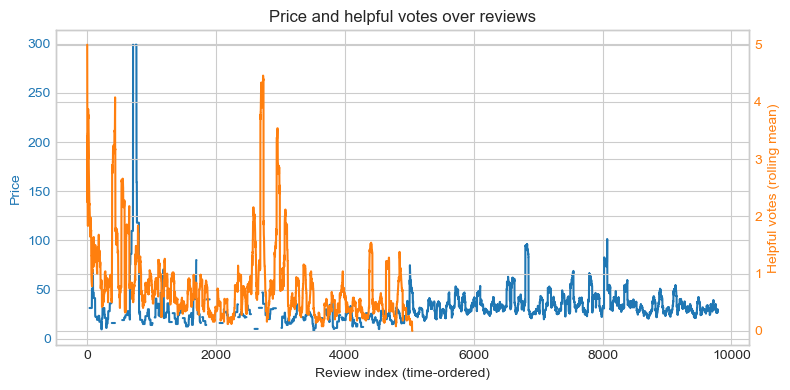

In [98]:
#store popularity

# sort by date to give a sensible order
#df["review_date"] = pd.to_datetime(df["review_date"])
df_sorted = df.sort_values("review_date").reset_index(drop=True)

# rolling averages to smooth noise (optional)
df_sorted["price_roll"] = df_sorted["price"].rolling(50, min_periods=1).mean()
df_sorted["helpful_roll"] = df_sorted["helpful_vote"].rolling(50, min_periods=1).mean()

plt.style.use("seaborn-v0_8-whitegrid")
fig, ax1 = plt.subplots(figsize=(8, 4))

ax1.plot(df_sorted.index, df_sorted["price_roll"], color="tab:blue", label="Price")
ax1.set_xlabel("Review index (time-ordered)")
ax1.set_ylabel("Price", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")

ax2 = ax1.twinx()
ax2.plot(df_sorted.index, df_sorted["helpful_roll"], color="tab:orange", label="Helpful votes")
ax2.set_ylabel("Helpful votes (rolling mean)", color="tab:orange")
ax2.tick_params(axis="y", labelcolor="tab:orange")

plt.title("Price and helpful votes over reviews")
fig.tight_layout()
plt.show()


This plot links to Research Question 1 by showing how price and helpful votes evolve across the sample of time‑ordered reviews.

- The blue line shows that prices fluctuate widely early on, with several very expensive items, but later reviews cluster around lower, more stable prices, suggesting that most activity centres on mid‑priced products.
- The orange rolling‑mean line for helpful votes spikes mainly in the earlier part of the series, often around periods where price is higher or more volatile, indicating that attention and “helpfulness” are concentrated on a relatively small set of reviews and products rather than spread evenly across all items.

Together, this suggests that while higher‑priced items do not dominate the dataset overall, they attract disproportionate engagement in terms of helpful votes, consistent with the idea that perceived value and interest are shaped by both price level and how prominently a product is discussed in reviews.

# Conclusion 

Overall, the analysis suggests that strong, information‑rich customer feedback is at the heart of product and store success, while price and seasonality shape how that success plays out over time.  

## Product performance, text, and price  
- Products that attract longer, more detailed reviews and have well‑written descriptions tend to achieve higher rating volumes and better average scores, reflecting both stronger engagement and greater customer confidence.
- Price moderates these effects: as prices rise, customers appear more demanding, so expensive items can still sell well but face tougher scrutiny, which can dampen average ratings even when reviews remain detailed and plentiful.

## What drives store popularity  
- The most successful stores are those that combine high average ratings with a large and active review base across many products, signalling reliability and breadth to new shoppers.
- Regular inflows of recent reviews help these stores stay visible in search and recommendation systems, creating a virtuous circle in which good experiences generate trust, traffic, and further positive feedback.

## Seasonality in product popularity  
- Review volumes rise and fall across the calendar, with clear peaks around key shopping periods rather than a flat pattern, indicating that customer interest in these products is strongly seasonal.
- Although the exact timing and size of the peaks vary by year, the repeated surges around similar parts of the year point to a broadly stable seasonal structure, onto which individual years layer their own shocks and anomalies.